# Generalized Selective Classification in Medical Imaging

**Dataset:** ISIC 2019 (25,331 dermoscopic images, 8 classes) from Kaggle  
**Source:** https://www.kaggle.com/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification

In [ ]:
import sys, subprocess
from pathlib import Path

def pip_install(packages):
    for pkg in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

pip_install(["scikit-learn", "pandas", "seaborn", "tqdm"])

import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore", category=UserWarning)

IS_COLAB = "google.colab" in sys.modules
print(f"Colab: {IS_COLAB} | PyTorch: {torch.__version__}")

Colab: True | PyTorch: 2.10.0+cu128


In [ ]:
import numpy as np
import subprocess, sys, os, shutil
from pathlib import Path

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
import kagglehub

print("Downloading ISIC 2019 dataset from Kaggle (≈9 GB) ...")
raw_path = kagglehub.dataset_download(
    "salviohexia/isic-2019-skin-lesion-images-for-classification"
)
print(f"Downloaded to: {raw_path}")


def find_class_root(base):
    """Walk downward until we find a directory whose immediate children
    are the 8 ISIC class folders (AK, BCC, BKL, DF, MEL, NV, SCC, VASC)."""
    EXPECTED = {"AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"}
    for dirpath, dirnames, _ in os.walk(base):
        if EXPECTED.issubset(set(dirnames)):
            return dirpath
    return None

class_root = find_class_root(raw_path)

if class_root is None:
    # Fallback: maybe the classes are at the top level
    print("\nCould not find class subdirectories. Contents of download:")
    for item in sorted(os.listdir(raw_path)):
        full = os.path.join(raw_path, item)
        if os.path.isdir(full):
            children = os.listdir(full)[:5]
            print(f"  📁 {item}/  ({len(os.listdir(full))} items)  e.g. {children}")
        else:
            print(f"  📄 {item}  ({os.path.getsize(full)/1e6:.1f} MB)")
    raise FileNotFoundError(
        "Expected 8 class folders (AK, BCC, …, VASC) somewhere in the download. "
        "Check the structure above and adjust `class_root` manually."
    )

print(f"\nClass root: {class_root}")
class_dirs = sorted([d for d in os.listdir(class_root)
                      if os.path.isdir(os.path.join(class_root, d))])
print(f"Classes found: {class_dirs}")
for d in class_dirs:
    n = len(os.listdir(os.path.join(class_root, d)))
    print(f"  {d}: {n} images")

# train / val / test split (70 / 15 / 15)

SPLIT_DIR = "./data/isic2019"
SPLITS    = {"train": 0.70, "val": 0.15, "test": 0.15}

if os.path.isdir(os.path.join(SPLIT_DIR, "train")):
    print(f"\nSplit already exists at {SPLIT_DIR} — skipping.")
else:
    print(f"\nCreating stratified split in {SPLIT_DIR} ...")
    rng = np.random.RandomState(42)

    for split in SPLITS:
        for cls in class_dirs:
            Path(os.path.join(SPLIT_DIR, split, cls)).mkdir(parents=True, exist_ok=True)

    for cls in class_dirs:
        src_dir = os.path.join(class_root, cls)
        files   = sorted(os.listdir(src_dir))
        rng.shuffle(files)

        n      = len(files)
        n_train = int(n * SPLITS["train"])
        n_val   = int(n * SPLITS["val"])
        # rest goes to test

        split_files = {
            "train": files[:n_train],
            "val":   files[n_train:n_train + n_val],
            "test":  files[n_train + n_val:],
        }

        for split, flist in split_files.items():
            dst_dir = os.path.join(SPLIT_DIR, split, cls)
            for fname in flist:
                src = os.path.join(src_dir, fname)
                dst = os.path.join(dst_dir, fname)
                if not os.path.exists(dst):
                    # Symlink to avoid doubling disk usage
                    os.symlink(os.path.abspath(src), dst)

    # Print summary
    for split in SPLITS:
        total = sum(len(os.listdir(os.path.join(SPLIT_DIR, split, c))) for c in class_dirs)
        print(f"  {split}: {total} images")

print(f"\config['data_dir'] {SPLIT_DIR}")


<>:94: SyntaxWarning: invalid escape sequence '\c'
<>:94: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3844/3727311333.py:94: SyntaxWarning: invalid escape sequence '\c'
  print(f"\config['data_dir'] {SPLIT_DIR}")


Using Colab cache for faster access to the 'isic-2019-skin-lesion-images-for-classification' dataset.
Downloaded to: /kaggle/input/isic-2019-skin-lesion-images-for-classification

Class root: /kaggle/input/isic-2019-skin-lesion-images-for-classification
Classes found: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
  AK: 867 images
  BCC: 3323 images
  BKL: 2624 images
  DF: 239 images
  MEL: 4522 images
  NV: 12875 images
  SCC: 628 images
  VASC: 253 images

Creating stratified split in ./data/isic2019 ...
  train: 17728 images
  val: 3796 images
  test: 3807 images
\config['data_dir'] ./data/isic2019


In [ ]:
config = {
    # Dataset
    "dataset":     "isic2019",
    "data_dir":    "./data/isic2019",   # <-- SET THIS to your dataset path
    "num_classes": 8,
    "image_size":  224,
    "num_workers": 4,

    # ISIC 2019 class names (alphabetical order matching ImageFolder)
    "class_names": ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"],

    # Training — set to 5 for quick experiments, 15 for full training
    "batch_size":    32,
    "epochs":        15,        # ← CHANGE TO 5 FOR QUICK RUN
    "lr":            1e-4,      # lower LR for fine-tuning pretrained ResNet
    "weight_decay":  1e-4,
    "seed":          42,

    # Model
    "model_name":  "resnet18",
    "mc_dropout_p": 0.3,
    "mc_samples":   30,

    # Distribution shift simulation
    "shift_noise_std": 0.3,
    "shift_blur_k":    5,
    # Holdout rare classes for label-shift (Type B): DF and VASC are rarest
    "holdout_classes": [3, 7],  # DF=3, VASC=7 (in alphabetical ImageFolder order)

    # Temperature scaling
    "temp_lr":     0.01,
    "temp_epochs": 200,

    # Device
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Outputs
    "checkpoint_dir": "./checkpoints",
    "results_dir":    "./results",
}

for d in [config["checkpoint_dir"], config["results_dir"], config["data_dir"]]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(json.dumps({k: v for k, v in config.items() if k != "device"}, indent=2))
print(f"Device: {config['device']}")

{
  "dataset": "isic2019",
  "data_dir": "./data/isic2019",
  "num_classes": 8,
  "image_size": 224,
  "num_workers": 4,
  "class_names": [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
  ],
  "batch_size": 32,
  "epochs": 15,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "seed": 42,
  "model_name": "resnet18",
  "mc_dropout_p": 0.3,
  "mc_samples": 30,
  "shift_noise_std": 0.3,
  "shift_blur_k": 5,
  "holdout_classes": [
    3,
    7
  ],
  "temp_lr": 0.01,
  "temp_epochs": 200,
  "checkpoint_dir": "./checkpoints",
  "results_dir": "./results"
}
Device: cuda


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config["seed"])

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transforms(sz):
    return transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def get_val_transforms(sz):
    return transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

In [ ]:
class ISIC2019CSVDataset(Dataset):
    """ISIC 2019 dataset loaded from a flat image folder + ground truth CSV.
    The CSV has columns: image, MEL, NV, BCC, AK, BKL, DF, VASC, SCC (one-hot).
    """
    CLASS_NAMES = ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"]

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        from PIL import Image
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


def get_isic2019_loaders(config):
    """Load ISIC 2019. Tries ImageFolder first, falls back to CSV-based loading."""
    data_dir = config["data_dir"]
    sz = config["image_size"]
    bs = config["batch_size"]
    nw = config["num_workers"]
    pin = torch.cuda.is_available()

    # --- Strategy 1: Pre-split ImageFolder (train/val/test subdirs) ---
    train_dir = os.path.join(data_dir, "train")
    val_dir   = os.path.join(data_dir, "val")
    test_dir  = os.path.join(data_dir, "test")

    if os.path.isdir(train_dir) and (os.path.isdir(val_dir) or os.path.isdir(test_dir)):
        print("Found ImageFolder structure (train/val/test subdirs).")
        train_ds = ImageFolder(train_dir, transform=get_train_transforms(sz))
        val_ds   = ImageFolder(val_dir,   transform=get_val_transforms(sz)) if os.path.isdir(val_dir) else None
        test_ds  = ImageFolder(test_dir,  transform=get_val_transforms(sz)) if os.path.isdir(test_dir) else None

        # If only train+test exist, split test into val+test
        if val_ds is None and test_ds is not None:
            n = len(test_ds)
            n_val = n // 2
            val_ds  = Subset(test_ds, range(n_val))
            test_ds = Subset(test_ds, range(n_val, n))
        elif val_ds is not None and test_ds is None:
            test_ds = val_ds  # use val as test

        config["num_classes"] = len(train_ds.classes)
        config["class_names"] = train_ds.classes
        CLASS_NAMES = train_ds.classes

        train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=nw, pin_memory=pin)
        val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)
        test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)

        print(f"ISIC 2019: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")
        print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
        return train_loader, val_loader, test_loader

    # Single image dir + CSV ground truth
    # Look for the CSV and image directory
    csv_candidates = [
        os.path.join(data_dir, "ISIC_2019_Training_GroundTruth.csv"),
        os.path.join(data_dir, "labels.csv"),
        os.path.join(data_dir, "train.csv"),
    ]
    img_dir_candidates = [
        os.path.join(data_dir, "ISIC_2019_Training_Input"),
        os.path.join(data_dir, "images"),
        os.path.join(data_dir, "train_images"),
        data_dir,  # images might be directly in data_dir
    ]

    csv_path = None
    for c in csv_candidates:
        if os.path.isfile(c):
            csv_path = c
            break

    img_dir = None
    for d in img_dir_candidates:
        if os.path.isdir(d):
            # Check if it actually contains images
            sample_files = [f for f in os.listdir(d)[:10] if f.endswith(('.jpg', '.jpeg', '.png'))]
            if sample_files:
                img_dir = d
                break

    print(f"Loading from CSV: {csv_path}")
    print(f"Image directory:  {img_dir}")

    df = pd.read_csv(csv_path)
    # Expected columns: image, MEL, NV, BCC, AK, BKL, DF, VASC, SCC
    class_cols = [c for c in ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"] if c in df.columns]
    if not class_cols:
        # Try: first column is image id, remaining are class labels
        class_cols = df.columns[1:].tolist()

    # Convert one-hot to integer labels
    label_matrix = df[class_cols].values
    labels_int = label_matrix.argmax(axis=1)

    # Map to sorted class names for consistency
    sorted_classes = sorted(class_cols)
    class_to_sorted_idx = {c: sorted_classes.index(c) for c in class_cols}
    labels_sorted = np.array([class_to_sorted_idx[class_cols[l]] for l in labels_int])

    # Build image paths
    img_col = df.columns[0]  # first column is image ID
    extensions = [".jpg", ".jpeg", ".png", ""]
    image_paths = []
    valid_mask = []
    for img_id in df[img_col]:
        found = False
        for ext in extensions:
            p = os.path.join(img_dir, f"{img_id}{ext}")
            if os.path.isfile(p):
                image_paths.append(p)
                valid_mask.append(True)
                found = True
                break
        if not found:
            valid_mask.append(False)

    valid_mask = np.array(valid_mask)
    image_paths = np.array(image_paths)
    labels_sorted = labels_sorted[valid_mask]
    print(f"Found {valid_mask.sum()} / {len(valid_mask)} images")

    # Stratified split: 70% train, 15% val, 15% test
    from sklearn.model_selection import train_test_split
    idx_all = np.arange(len(labels_sorted))
    idx_train, idx_temp, y_train, y_temp = train_test_split(
        idx_all, labels_sorted, test_size=0.3, stratify=labels_sorted, random_state=config["seed"]
    )
    idx_val, idx_test, _, _ = train_test_split(
        idx_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=config["seed"]
    )

    config["num_classes"] = len(sorted_classes)
    config["class_names"] = sorted_classes

    train_ds = ISIC2019CSVDataset(image_paths[idx_train], labels_sorted[idx_train],
                                   transform=get_train_transforms(sz))
    val_ds   = ISIC2019CSVDataset(image_paths[idx_val],   labels_sorted[idx_val],
                                   transform=get_val_transforms(sz))
    test_ds  = ISIC2019CSVDataset(image_paths[idx_test],  labels_sorted[idx_test],
                                   transform=get_val_transforms(sz))

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=nw, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)

    print(f"ISIC 2019: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")
    print(f"Classes ({len(sorted_classes)}): {sorted_classes}")

    # Print class distribution
    for split_name, split_labels in [("Train", labels_sorted[idx_train]),
                                      ("Val",   labels_sorted[idx_val]),
                                      ("Test",  labels_sorted[idx_test])]:
        counts = np.bincount(split_labels, minlength=len(sorted_classes))
        dist = ", ".join(f"{sorted_classes[i]}={counts[i]}" for i in range(len(sorted_classes)))
        print(f"  {split_name}: {dist}")

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_isic2019_loaders(config)

CLASS_NAMES = config["class_names"]
print(f"\nUsing {config['num_classes']} classes: {CLASS_NAMES}")

Found ImageFolder structure (train/val/test subdirs).
ISIC 2019: train=17728 val=3796 test=3807
Classes (8): ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

Using 8 classes: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


## 4. Model — ResNet-18 + MC Dropout Variant

In [ ]:
class MCDropoutResNet(nn.Module):
    """ResNet with a dropout layer before the final FC, kept active at test time.
    Enables Monte Carlo Dropout uncertainty estimation.
    """
    def __init__(self, base_model, p=0.3):
        super().__init__()
        # Everything except the final FC
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        in_features = base_model.fc.in_features
        self.drop = nn.Dropout(p=p)
        self.fc   = base_model.fc

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        x = self.drop(x)
        return self.fc(x)

    def get_features(self, x):
        """Return penultimate-layer features (before dropout and FC)."""
        with torch.no_grad():
            x = self.features(x)
            return x.flatten(1)


def build_model(config):
    name = config["model_name"]
    nc   = config["num_classes"]

    if name == "resnet18":
        base = models.resnet18(weights="IMAGENET1K_V1")
        base.fc = nn.Linear(base.fc.in_features, nc)
    elif name == "resnet50":
        base = models.resnet50(weights="IMAGENET1K_V2")
        base.fc = nn.Linear(base.fc.in_features, nc)
    elif name == "densenet121":
        base = models.densenet121(weights="IMAGENET1K_V1")
        base.classifier = nn.Linear(base.classifier.in_features, nc)
    else:
        raise ValueError(f"Unknown model: {name}")

    model = MCDropoutResNet(base, p=config["mc_dropout_p"])
    return model.to(config["device"])


model = build_model(config)
print(f"Model: {config['model_name']} | classes: {config['num_classes']} | dropout: {config['mc_dropout_p']}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]


Model: resnet18 | classes: 8 | dropout: 0.3


## 5. Training

Using weighted cross-entropy to handle the severe class imbalance in ISIC 2019.
NV alone is ~51% of the dataset; DF and VASC are <1% each.

In [ ]:
def compute_class_weights(loader, num_classes):
    """Compute inverse-frequency class weights from the training loader."""
    counts = torch.zeros(num_classes)
    for _, labels in loader:
        if labels.dim() > 1:
            labels = (labels.squeeze() if labels.dim() > 1 else labels)
        for c in range(num_classes):
            counts[c] += (labels == c).sum().item()
    # Inverse frequency, normalized
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes
    return weights

class_weights = compute_class_weights(train_loader, config["num_classes"])
print("Class weights:", {CLASS_NAMES[i]: f"{class_weights[i]:.3f}" for i in range(config["num_classes"])})


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc="train"):
        images = images.to(device)
        labels = labels.squeeze().long().to(device) if labels.dim() > 1 else labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="val"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc=desc):
        images = images.to(device)
        labels = labels.squeeze().long().to(device) if labels.dim() > 1 else labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

Class weights: {'AK': '0.778', 'BCC': '0.203', 'BKL': '0.257', 'DF': '2.823', 'MEL': '0.149', 'NV': '0.052', 'SCC': '1.074', 'VASC': '2.664'}


In [ ]:
# Weighted cross-entropy for imbalanced ISIC 2019
criterion  = nn.CrossEntropyLoss(weight=class_weights.to(config["device"]))
optimizer  = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
ckpt_path  = os.path.join(config["checkpoint_dir"], "best_model.pt")

history     = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

print(f"Training for {config['epochs']} epochs on ISIC 2019 ({config['num_classes']} classes)...")
print(f"Device: {config['device']}")

for epoch in range(1, config["epochs"] + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, config["device"])
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, config["device"])
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Ep {epoch:02d}/{config['epochs']} | "
          f"Train {tr_loss:.4f}/{tr_acc:.4f} | Val {vl_loss:.4f}/{vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        print(f"  ✓ Best val acc: {best_val_acc:.4f}")

print(f"\nDone. Best val acc = {best_val_acc:.4f}")

Training for 15 epochs on ISIC 2019 (8 classes)...
Device: cuda


train:   0%|          | 0/554 [00:00<?, ?it/s]

val:   0%|          | 0/119 [00:00<?, ?it/s]

Ep 01/15 | Train 1.5049/0.4957 | Val 1.0789/0.5914
  ✓ Best val acc: 0.5914


train:   0%|          | 0/554 [00:00<?, ?it/s]

...

train:   0%|          | 0/554 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3fea688360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3fea688360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

val:   0%|          | 0/119 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3fea688360>
Traceback (most recent call last):
self._shutdown_workers()      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3fea688360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Ep 15/15 | Train 0.4217/0.7890 | Val 0.6605/0.7592
  ✓ Best val acc: 0.7592

Done. Best val acc = 0.7592


## 6. Training Curves

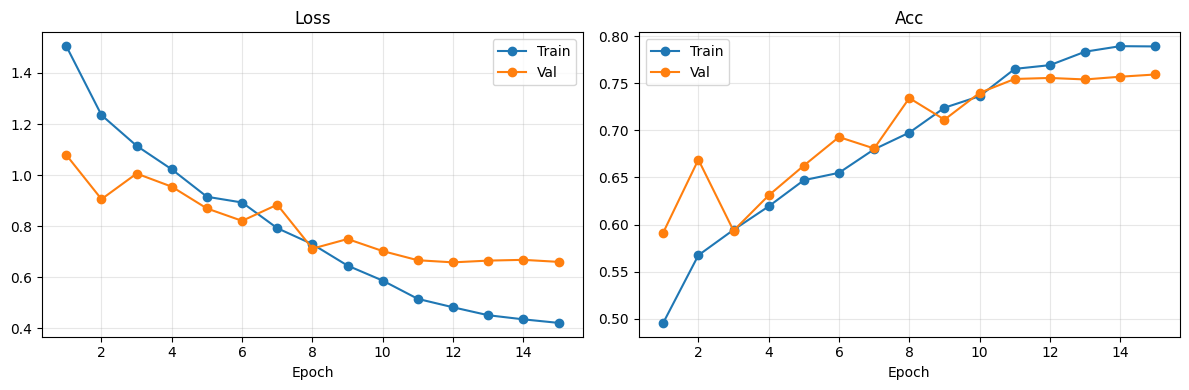

Saved: ./results/training_curves.png


In [ ]:
def plot_training_curves(history, save_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "acc"]):
        ax.plot(epochs, history[f"train_{metric}"], marker="o", label="Train")
        ax.plot(epochs, history[f"val_{metric}"],   marker="o", label="Val")
        ax.set_title(metric.capitalize())
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    p = os.path.join(save_dir, "training_curves.png")
    plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

plot_training_curves(history, config["results_dir"])

## 7. Baseline Inference on Test Set

In [ ]:
@torch.no_grad()
def run_inference(model, loader, device, desc="test"):
    """Collect logits, probs, preds, labels over a dataloader."""
    model.eval()
    all_logits, all_labels = [], []
    for images, labels in tqdm(loader, leave=False, desc=desc):
        all_logits.append(model(images.to(device)).cpu())
        lbl = labels.squeeze().long() if labels.dim() > 1 else labels
        all_labels.append(lbl.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probs  = torch.softmax(logits, dim=1)
    preds  = logits.argmax(dim=1)
    return {
        "logits": logits.numpy(),
        "probs":  probs.numpy(),
        "preds":  preds.numpy(),
        "labels": labels.numpy(),
    }


# Load best checkpoint
model.load_state_dict(torch.load(ckpt_path, map_location=config["device"]))

res = run_inference(model, test_loader, config["device"])

test_acc = accuracy_score(res["labels"], res["preds"])
bal_acc  = balanced_accuracy_score(res["labels"], res["preds"])
print(f"Test acc: {test_acc:.4f}  |  Balanced acc: {bal_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(res["labels"], res["preds"], target_names=CLASS_NAMES, digits=4))

np.savez(os.path.join(config["results_dir"], "test_results.npz"), **res)

test:   0%|          | 0/119 [00:00<?, ?it/s]

Test acc: 0.7555  |  Balanced acc: 0.7391

Classification Report:
              precision    recall  f1-score   support

          AK     0.4859    0.6565    0.5584       131
         BCC     0.7616    0.8257    0.7923       499
         BKL     0.5754    0.6759    0.6217       395
          DF     0.6000    0.7297    0.6585        37
         MEL     0.6269    0.6804    0.6525       679
          NV     0.9098    0.7883    0.8447      1932
         SCC     0.5285    0.6842    0.5963        95
        VASC     0.7391    0.8718    0.8000        39

    accuracy                         0.7555      3807
   macro avg     0.6534    0.7391    0.6906      3807
weighted avg     0.7763    0.7555    0.7621      3807



## 8. Basic Confidence Scores and Selective Metrics

In [ ]:
# ----- Confidence scoring functions -----
# Each takes probs (N, C) or logits (N, C) and returns a (N,) score.
# Higher = more confident = more likely to be selected.

def score_msp(probs, logits=None):
    """Maximum softmax probability — Hendrycks & Gimpel 2016."""
    return probs.max(axis=1)


def score_margin(probs, logits=None):
    """Top-1 minus Top-2 probability margin."""
    s = np.sort(probs, axis=1)[:, ::-1]
    return s[:, 0] - s[:, 1]


def score_entropy(probs, logits=None):
    """Negative entropy (higher = more confident)."""
    eps = 1e-8
    return (probs * np.log(probs + eps)).sum(axis=1)  # negative of entropy


# ----- Selective metrics -----

def selective_metrics(preds, labels, scores, coverages=None):
    """Risk and accuracy at each coverage level.
    Samples sorted by descending confidence; top-k are 'selected'.
    """
    if coverages is None:
        coverages = np.linspace(0.05, 1.0, 40)
    n       = len(preds)
    correct = (preds == labels)
    order   = np.argsort(-scores)  # most confident first

    covs, risks, accs = [], [], []
    for c in coverages:
        k   = max(1, int(c * n))
        sel = order[:k]
        acc = correct[sel].mean()
        covs.append(k / n)
        risks.append(1.0 - acc)
        accs.append(acc)
    return {"coverage": np.array(covs), "risk": np.array(risks), "accuracy": np.array(accs)}


def aurc(metrics):
    return float(np.trapz(metrics["risk"], metrics["coverage"]))


def e_aurc(metrics, base_risk):
    """Excess AURC: AURC minus optimal AURC (ideal classifier).
    base_risk = error rate of the model at full coverage.
    """
    kappa_star = base_risk
    # Integral of the ideal oracle curve
    ideal = kappa_star * (1 - kappa_star) + kappa_star ** 2 / 2
    # Simpler: optimal AURC = kappa_star * (1 - kappa_star/2) ... approximate
    # Use empirical shorthand: eAURC = AURC - kappa_star
    return aurc(metrics) - kappa_star


# Run basic scorers on test set
probs  = res["probs"]
logits = res["logits"]
preds  = res["preds"]
labels = res["labels"]

base_risk = 1.0 - test_acc

basic_scorers = {
    "MSP":    score_msp(probs),
    "Margin": score_margin(probs),
    "Entropy": score_entropy(probs),
}

basic_sc = {name: selective_metrics(preds, labels, s) for name, s in basic_scorers.items()}

for name, m in basic_sc.items():
    print(f"{name:<12} AURC={aurc(m):.5f}  eAURC={e_aurc(m, base_risk):.5f}")

MSP          AURC=0.09260  eAURC=-0.15195
Margin       AURC=0.09410  eAURC=-0.15045
Entropy      AURC=0.09334  eAURC=-0.15121


/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


## 9. Basic Report Plots (Confusion Matrix, Confidence Histogram, ECE)

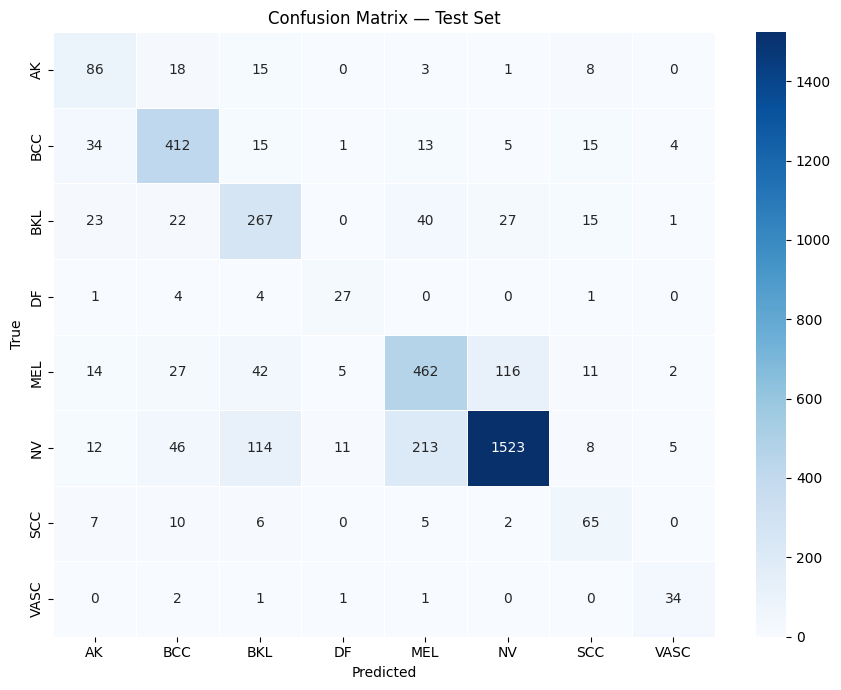

Saved: ./results/confusion_matrix.png


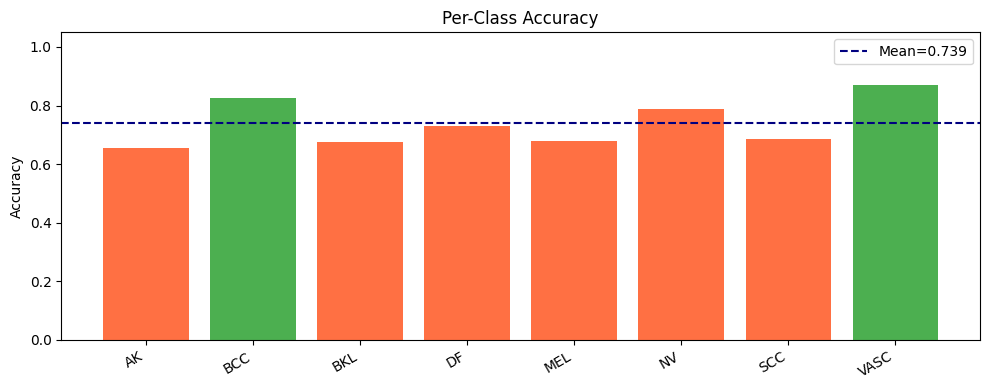

Saved: ./results/per_class_accuracy.png


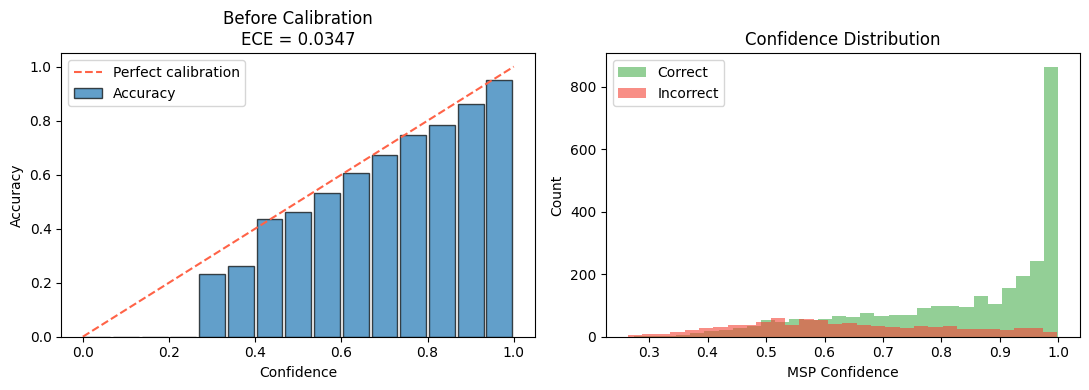

In [ ]:
def plot_confusion(y_true, y_pred, class_names, save_dir):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.title("Confusion Matrix — Test Set")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    p = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")


def plot_class_accuracy(y_true, y_pred, class_names, save_dir):
    cm  = confusion_matrix(y_true, y_pred)
    acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(class_names, acc, color=["#4CAF50" if a >= 0.8 else "#FF7043" for a in acc])
    ax.axhline(acc.mean(), color="navy", linestyle="--", label=f"Mean={acc.mean():.3f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Per-Class Accuracy")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    p = os.path.join(save_dir, "per_class_accuracy.png")
    plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")
    return acc


def compute_ece(probs, y_true, n_bins=15):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    cor  = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece, bin_accs, bin_confs, bin_counts = 0.0, [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            bin_accs.append(0.); bin_confs.append((lo+hi)/2); bin_counts.append(0)
            continue
        a = cor[mask].mean(); c = conf[mask].mean()
        ece += abs(a - c) * mask.mean()
        bin_accs.append(a); bin_confs.append(c); bin_counts.append(mask.sum())
    return ece, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts), bins


def plot_reliability(probs, y_true, title="Reliability Diagram", save_path=None):
    ece, bin_accs, bin_confs, bin_counts, bins = compute_ece(probs, y_true)
    centers = 0.5 * (bins[:-1] + bins[1:])
    w       = bins[1] - bins[0]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Reliability diagram
    axes[0].bar(centers, bin_accs, width=w*0.9, alpha=0.7, edgecolor="k", label="Accuracy")
    axes[0].plot([0,1],[0,1], "--", color="tomato", label="Perfect calibration")
    axes[0].set_xlabel("Confidence"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{title}\nECE = {ece:.4f}")
    axes[0].legend()

    # Confidence histogram
    conf = probs.max(axis=1)
    cor  = (probs.argmax(axis=1) == y_true)
    axes[1].hist(conf[cor],  bins=30, alpha=0.6, label="Correct",   color="#4CAF50")
    axes[1].hist(conf[~cor], bins=30, alpha=0.6, label="Incorrect", color="#F44336")
    axes[1].set_xlabel("MSP Confidence"); axes[1].set_ylabel("Count")
    axes[1].set_title("Confidence Distribution")
    axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return ece


plot_confusion(labels, preds, CLASS_NAMES, config["results_dir"])
per_class_acc = plot_class_accuracy(labels, preds, CLASS_NAMES, config["results_dir"])
baseline_ece  = plot_reliability(
    probs, labels, title="Before Calibration",
    save_path=os.path.join(config["results_dir"], "reliability_baseline.png")
)

## 10. Temperature Scaling

Post-hoc calibration: learn a single scalar T on the validation set.
No model retraining required. Improves ECE substantially.

collecting val logits:   0%|          | 0/119 [00:00<?, ?it/s]

Optimal temperature T = 1.2097


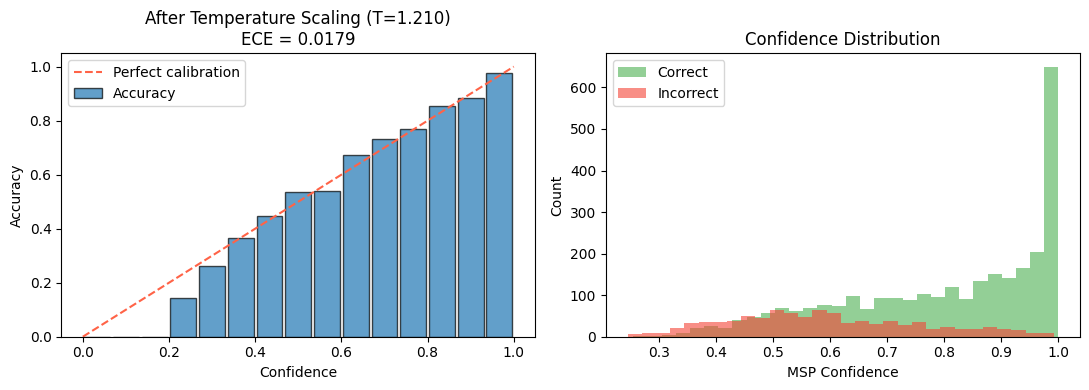


ECE before calibration: 0.0347
ECE after  calibration: 0.0179
Improvement:            0.0169


In [ ]:
class TemperatureScaler(nn.Module):
    """Wraps a model and adds a learnable temperature parameter."""
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        return self.model(x) / self.temperature

    def scale_logits(self, logits):
        return logits / self.temperature.item()


def fit_temperature(model, val_loader, device, lr=0.01, max_iter=200):
    """Optimize T to minimize NLL on val set. Returns fitted TemperatureScaler."""
    # Collect val logits (frozen model)
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, lbls in tqdm(val_loader, leave=False, desc="collecting val logits"):
            all_logits.append(model(images.to(device)).cpu())
            all_labels.append((lbls.squeeze() if lbls.dim() > 1 else lbls).cpu())
    val_logits = torch.cat(all_logits)
    val_labels = torch.cat(all_labels)

    scaler = TemperatureScaler(model).to(device)
    # Only optimize the temperature parameter
    optimizer = optim.LBFGS([scaler.temperature], lr=lr, max_iter=max_iter)
    criterion = nn.CrossEntropyLoss()

    val_logits_dev = val_logits.to(device)
    val_labels_dev = val_labels.to(device)

    def closure():
        optimizer.zero_grad()
        scaled = val_logits_dev / scaler.temperature
        loss   = criterion(scaled, val_labels_dev)
        loss.backward()
        return loss

    optimizer.step(closure)

    T = scaler.temperature.item()
    print(f"Optimal temperature T = {T:.4f}")
    return scaler, T


temp_scaler, T_opt = fit_temperature(model, val_loader, config["device"],
                                      lr=config["temp_lr"], max_iter=config["temp_epochs"])

# Apply temperature to test logits
logits_scaled = logits / T_opt
probs_scaled  = torch.softmax(torch.tensor(logits_scaled), dim=1).numpy()

ece_after = plot_reliability(
    probs_scaled, labels, title=f"After Temperature Scaling (T={T_opt:.3f})",
    save_path=os.path.join(config["results_dir"], "reliability_calibrated.png")
)

print(f"\nECE before calibration: {baseline_ece:.4f}")
print(f"ECE after  calibration: {ece_after:.4f}")
print(f"Improvement:            {baseline_ece - ece_after:.4f}")

## 11. Advanced Confidence Scores

Implementing: Energy score, ODIN (temperature-only), Doctor score, and RLconf-K  
(the margin-family score from Liang et al. 2024).

In [ ]:
# ---- Energy Score (Liu et al. 2020) ----
def score_energy(probs, logits, T=1.0):
    """Energy = -T * log(sum(exp(logits/T))).
    Negated so that higher score = more confident (lower energy = in-distribution).
    Uses log-sum-exp trick for numerical stability.
    """
    max_logit = logits.max(axis=1, keepdims=True)
    energy = -T * (max_logit.squeeze(1) + np.log(np.exp((logits - max_logit) / T).sum(axis=1)))
    return -energy   # negate: high score → in-distribution → selected


# ---- ODIN — temperature scaling only (Liang et al. 2018) ----
def score_odin_temp(probs, logits, T=1000.0):
    """ODIN with temperature scaling only (no input perturbation).
    High T softens the distribution, making ID/OOD more separable.
    """
    shifted = logits - logits.max(axis=1, keepdims=True)  # numerical stability
    probs_T = np.exp(shifted / T) / np.exp(shifted / T).sum(axis=1, keepdims=True)
    return probs_T.max(axis=1)


# ---- Full ODIN with input perturbation (Liang et al. 2018) ----
def score_odin_full(model, loader, device, T=1000.0, epsilon=0.0014):
    """Full ODIN: temperature scaling + input perturbation."""
    model.eval()
    all_scores = []
    for images, _ in loader:
        images = images.to(device)
        images.requires_grad_(True)
        logits = model(images)
        scaled = logits / T
        probs_T = torch.softmax(scaled, dim=1)
        max_probs, _ = probs_T.max(dim=1)
        loss = max_probs.sum()
        loss.backward()
        grad_sign = images.grad.data.sign()
        perturbed = images - epsilon * grad_sign
        with torch.no_grad():
            logits_pert = model(perturbed)
            scaled_pert = logits_pert / T
            probs_pert  = torch.softmax(scaled_pert, dim=1)
            scores_batch = probs_pert.max(dim=1).values.cpu().numpy()
        all_scores.append(scores_batch)
        images.requires_grad_(False)
    return np.concatenate(all_scores, axis=0)


# ---- Doctor Score (Geifman & El-Yaniv 2017) ----
def score_doctor(probs, logits=None):
    """Doctor = 1 - p_hat^2 / sum(p^2). Negate so high = confident."""
    p_hat  = probs.max(axis=1)
    p_sq   = (probs ** 2).sum(axis=1)
    doctor = 1.0 - p_hat ** 2 / (p_sq + 1e-8)
    return -doctor


# ---- RLconf-K (Liang et al. 2024) ----
def score_rlconf_k(probs, logits, K=2):
    """Ratio of top-1 logit to K-th logit (relative logit confidence)."""
    sorted_logits = np.sort(logits, axis=1)[:, ::-1]
    top1 = sorted_logits[:, 0]
    topK = sorted_logits[:, min(K - 1, sorted_logits.shape[1] - 1)]
    return top1 - topK


# ---- RLgeo-M: geometric-mean variant (Liang et al. 2024) ----
def score_rlgeo_m(probs, logits, M=3):
    """Geometric mean of top-M logit gaps."""
    sorted_logits = np.sort(logits, axis=1)[:, ::-1]
    M_actual = min(M, sorted_logits.shape[1] - 1)
    top1 = sorted_logits[:, 0:1]
    gaps = top1 - sorted_logits[:, 1:M_actual+1]
    gaps = np.clip(gaps, 1e-8, None)
    return np.exp(np.log(gaps).mean(axis=1))


# ---- Collect all scorers ----
advanced_scorers = {
    "MSP":          score_msp(probs),
    "MSP-T (cal.)": score_odin_temp(probs, logits, T=T_opt),
    "Margin":       score_margin(probs),
    "Entropy":      score_entropy(probs),
    "Energy":       score_energy(probs, logits),
    "ODIN (T=1k)": score_odin_temp(probs, logits, T=1000.0),
    "Doctor":       score_doctor(probs),
    "RLconf-2":     score_rlconf_k(probs, logits, K=2),
    "RLconf-5":     score_rlconf_k(probs, logits, K=5),
    "RLgeo-3":      score_rlgeo_m(probs, logits, M=3),
}

sc_all = {name: selective_metrics(preds, labels, s) for name, s in advanced_scorers.items()}

print(f"{'Scorer':<18} {'AURC':>8} {'eAURC':>8}")
print("-" * 36)
for name, m in sc_all.items():
    print(f"{name:<18} {aurc(m):>8.5f} {e_aurc(m, base_risk):>8.5f}")

Scorer                 AURC    eAURC
------------------------------------
MSP                 0.09260 -0.15195
MSP-T (cal.)        0.09220 -0.15235
Margin              0.09410 -0.15045
Entropy             0.09334 -0.15121
Energy              0.12432 -0.12023
ODIN (T=1k)         0.11747 -0.12708
Doctor              0.09463 -0.14992
RLconf-2            0.09637 -0.14818
RLconf-5            0.13023 -0.11432
RLgeo-3             0.09240 -0.15215


/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


/tmp/ipykernel_3844/4170959092.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(sc_dict))
/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


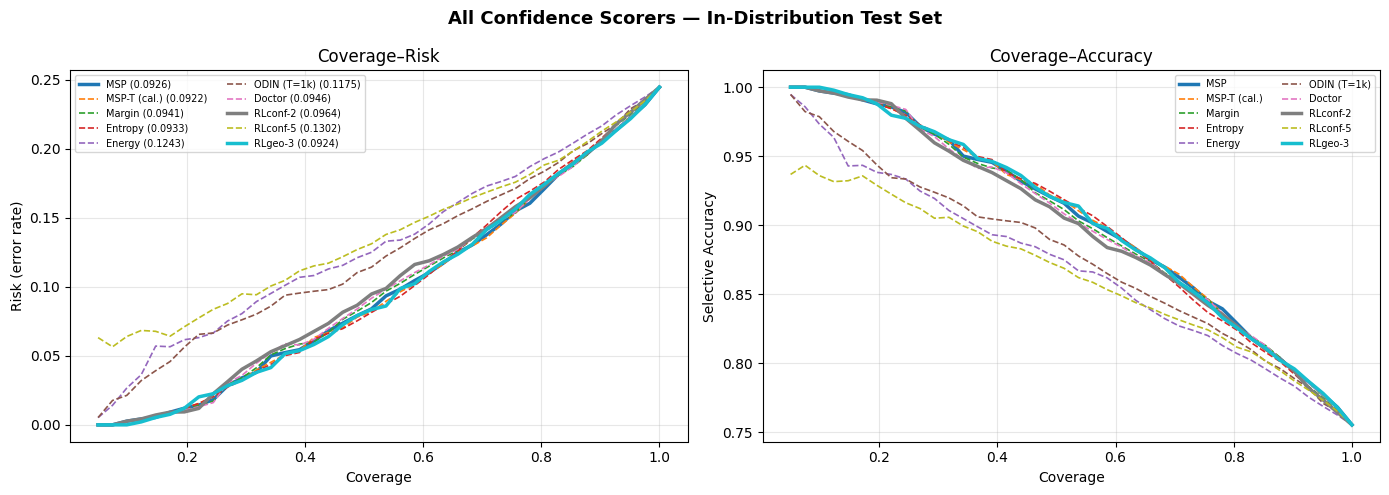

Saved: ./results/coverage_risk_all_scorers.png


In [ ]:
def plot_coverage_risk_multi(sc_dict, title, save_path, highlight=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cmap = plt.cm.get_cmap("tab10", len(sc_dict))

    for i, (name, m) in enumerate(sc_dict.items()):
        a = aurc(m)
        lw  = 2.5 if (highlight and name in highlight) else 1.2
        ls  = "-"  if (highlight and name in highlight) else "--"
        col = cmap(i)
        axes[0].plot(m["coverage"], m["risk"],     color=col, lw=lw, ls=ls, label=f"{name} ({a:.4f})")
        axes[1].plot(m["coverage"], m["accuracy"], color=col, lw=lw, ls=ls, label=name)

    for ax, ylabel, ytitle in zip(axes, ["Risk (error rate)", "Selective Accuracy"],
                                         ["Coverage–Risk", "Coverage–Accuracy"]):
        ax.set_xlabel("Coverage")
        ax.set_ylabel(ylabel)
        ax.set_title(ytitle)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.show()
    print(f"Saved: {save_path}")


plot_coverage_risk_multi(
    sc_all,
    title="All Confidence Scorers — In-Distribution Test Set",
    save_path=os.path.join(config["results_dir"], "coverage_risk_all_scorers.png"),
    highlight=["RLconf-2", "RLgeo-3", "MSP"]
)

## 12. MC Dropout Uncertainty

Run T stochastic forward passes with dropout active. Use variance / entropy of
predictive distribution as uncertainty estimate.

In [ ]:
def mc_dropout_inference(model, loader, device, n_samples=30):
    """Run n_samples stochastic forward passes. Dropout stays ON (train mode)."""
    # Enable dropout during inference by using train mode but no gradient
    model.train()
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            m.eval()

    all_probs_list = []   # list of (N, C) arrays, one per sample
    all_labels     = []

    # Collect labels in one pass
    with torch.no_grad():
        for i in range(n_samples):
            batch_probs = []
            for images, labels in loader:
                logits = model(images.to(device))
                batch_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
                if i == 0:
                    all_labels.append((labels.squeeze() if labels.dim() > 1 else labels).numpy())
            all_probs_list.append(np.concatenate(batch_probs, axis=0))

    model.eval()   # restore eval mode

    # Stack: (n_samples, N, C)
    all_probs  = np.stack(all_probs_list, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    mean_probs = all_probs.mean(axis=0)          # (N, C) — mean predictive distribution
    var_probs  = all_probs.var(axis=0)           # (N, C) — variance

    # Confidence scores from MC Dropout
    mc_msp      = mean_probs.max(axis=1)                              # mean MSP
    mc_entropy  = -(mean_probs * np.log(mean_probs + 1e-8)).sum(1)    # predictive entropy
    mc_var_mean = var_probs.mean(axis=1)                              # mean variance (epistemic proxy)

    preds_mc = mean_probs.argmax(axis=1)

    return {
        "mean_probs":  mean_probs,
        "var_probs":   var_probs,
        "preds":       preds_mc,
        "labels":      all_labels,
        "mc_msp":      mc_msp,
        "mc_entropy":  mc_entropy,
        "mc_var_mean": mc_var_mean,
    }


print(f"Running {config['mc_samples']} MC Dropout passes ...")
mc_res = mc_dropout_inference(model, test_loader, config["device"],
                               n_samples=config["mc_samples"])

mc_acc = accuracy_score(mc_res["labels"], mc_res["preds"])
print(f"MC Dropout test accuracy: {mc_acc:.4f}")

# Add MC Dropout scorers to comparison
mc_preds  = mc_res["preds"]
mc_labels = mc_res["labels"]

mc_scorers = {
    "MC-MSP":      mc_res["mc_msp"],
    "MC-Entropy":  -mc_res["mc_entropy"],    # negate: lower entropy = more confident
    "MC-Variance": -mc_res["mc_var_mean"],   # negate: lower variance = more confident
}

sc_mc = {name: selective_metrics(mc_preds, mc_labels, s) for name, s in mc_scorers.items()}

mc_base_risk = 1.0 - mc_acc
print(f"\n{'MC Scorer':<18} {'AURC':>8} {'eAURC':>8}")
print("-" * 36)
for name, m in sc_mc.items():
    print(f"{name:<18} {aurc(m):>8.5f} {e_aurc(m, mc_base_risk):>8.5f}")

Running 30 MC Dropout passes ...
MC Dropout test accuracy: 0.7562

MC Scorer              AURC    eAURC
------------------------------------
MC-MSP              0.09244 -0.15133
MC-Entropy          0.09366 -0.15010
MC-Variance         0.09907 -0.14469


/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


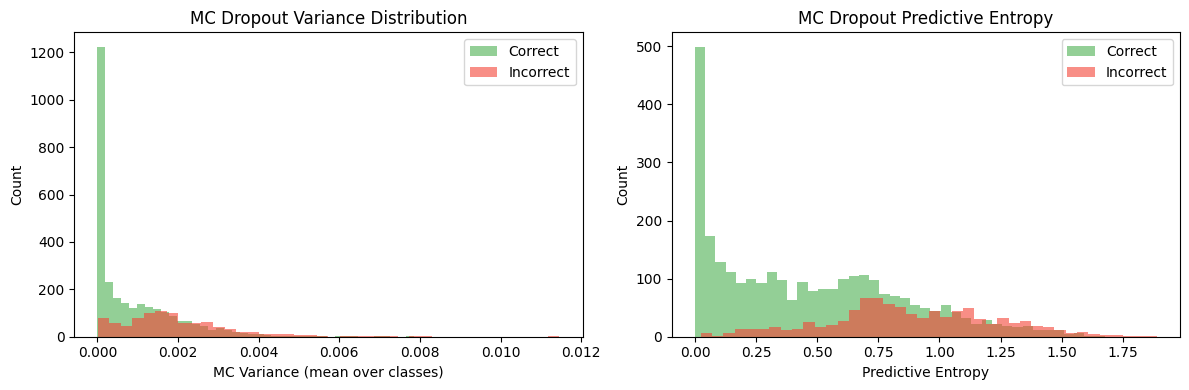

Saved: ./results/mc_dropout_uncertainty.png


In [ ]:
# Visualize MC Dropout uncertainty: variance vs. correctness
correct_mask = (mc_preds == mc_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mc_res["mc_var_mean"][correct_mask],  bins=40, alpha=0.6, label="Correct",   color="#4CAF50")
axes[0].hist(mc_res["mc_var_mean"][~correct_mask], bins=40, alpha=0.6, label="Incorrect", color="#F44336")
axes[0].set_xlabel("MC Variance (mean over classes)")
axes[0].set_ylabel("Count")
axes[0].set_title("MC Dropout Variance Distribution")
axes[0].legend()

axes[1].hist(mc_res["mc_entropy"][correct_mask],  bins=40, alpha=0.6, label="Correct",   color="#4CAF50")
axes[1].hist(mc_res["mc_entropy"][~correct_mask], bins=40, alpha=0.6, label="Incorrect", color="#F44336")
axes[1].set_xlabel("Predictive Entropy")
axes[1].set_ylabel("Count")
axes[1].set_title("MC Dropout Predictive Entropy")
axes[1].legend()

plt.tight_layout()
p = os.path.join(config["results_dir"], "mc_dropout_uncertainty.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 13. Covariate Shift Simulation — Type C Errors

Simulate scanner/acquisition domain shift by applying corruptions to the test set.
This mimics what happens when a model trained at one hospital sees data from another.
We test three corruptions at increasing severity.

In [ ]:
class CorruptedDataset(torch.utils.data.Dataset):
    """Wraps an existing dataset and applies a corruption transform on top."""
    def __init__(self, base_dataset, corruption_fn):
        self.base = base_dataset
        self.corrupt = corruption_fn

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, label = self.base[idx]
        return self.corrupt(image), label


def make_corruption(kind, severity):
    """Return a tensor→tensor corruption function."""
    if kind == "gaussian_noise":
        def fn(x): return torch.clamp(x + torch.randn_like(x) * severity, -3, 3)
    elif kind == "gaussian_blur":
        k = int(severity * 10) | 1
        blur = transforms.GaussianBlur(kernel_size=max(3, k), sigma=severity)
        def fn(x): return blur(x)
    elif kind == "brightness":
        def fn(x): return torch.clamp(x + severity, -3, 3)
    elif kind == "contrast":
        def fn(x): return torch.clamp(x * (1 + severity), -3, 3)
    else:
        raise ValueError(kind)
    return fn


# Build a clean test dataset (without transforms applied yet — need raw dataset)
# We need to get the underlying dataset from the test_loader
clean_test_ds = test_loader.dataset

CORRUPTIONS = {
    "Clean":            None,
    "Noise (mild)":     make_corruption("gaussian_noise", 0.1),
    "Noise (severe)":   make_corruption("gaussian_noise", 0.4),
    "Blur (mild)":      make_corruption("gaussian_blur",  0.5),
    "Blur (severe)":    make_corruption("gaussian_blur",  2.0),
    "Brightness (mild)": make_corruption("brightness",   0.3),
    "Brightness (sev.)": make_corruption("brightness",   1.0),
    "Contrast (mild)":   make_corruption("contrast",     0.5),
    "Contrast (sev.)": make_corruption("contrast",       2.0),
}

def make_loader(ds, config):
    return DataLoader(ds, batch_size=config["batch_size"], shuffle=False,
                      num_workers=config["num_workers"], pin_memory=torch.cuda.is_available())


corrupt_loaders = {}
for name, fn in CORRUPTIONS.items():
    if fn is None:
        corrupt_loaders[name] = test_loader
    else:
        corrupt_loaders[name] = make_loader(CorruptedDataset(clean_test_ds, fn), config)

print(f"Built {len(corrupt_loaders)} corrupted test loaders.")

Built 9 corrupted test loaders.


In [ ]:
# Run inference on each corruption
corrupt_results = {}
for name, loader in corrupt_loaders.items():
    r = run_inference(model, loader, config["device"], desc=name[:15])
    acc = accuracy_score(r["labels"], r["preds"])
    corrupt_results[name] = {"res": r, "acc": acc}
    print(f"{name:<25} acc={acc:.4f}")

# AURC for MSP and RLconf-2 on each corrupted set
print(f"\n{'Corruption':<25} {'Acc':>6} {'AURC-MSP':>10} {'AURC-RLconf2':>13}")
print("-" * 56)
for name, data in corrupt_results.items():
    r = data["res"]
    s_msp = score_msp(r["probs"])
    s_rl2 = score_rlconf_k(r["probs"], r["logits"], K=2)
    m_msp = selective_metrics(r["preds"], r["labels"], s_msp)
    m_rl2 = selective_metrics(r["preds"], r["labels"], s_rl2)
    print(f"{name:<25} {data['acc']:>6.4f} {aurc(m_msp):>10.5f} {aurc(m_rl2):>13.5f}")

Clean:   0%|          | 0/119 [00:00<?, ?it/s]

Clean                     acc=0.7555


Noise (mild):   0%|          | 0/119 [00:00<?, ?it/s]

Noise (mild)              acc=0.6648


Noise (severe):   0%|          | 0/119 [00:00<?, ?it/s]

...

Contrast (mild):   0%|          | 0/119 [00:05<?, ?it/s]

Contrast (mild)           acc=0.7376


Contrast (sev.):   0%|          | 0/119 [00:00<?, ?it/s]

Contrast (sev.)           acc=0.5075

Corruption                   Acc   AURC-MSP  AURC-RLconf2
--------------------------------------------------------
Clean                     0.7555    0.09260       0.09637
Noise (mild)              0.6648    0.17292       0.18095
Noise (severe)            0.1416    0.83645       0.83440
Blur (mild)               0.7457    0.09962       0.10484
Blur (severe)             0.6677    0.15358       0.15979
Brightness (mild)         0.7549    0.09401       0.09799
Brightness (sev.)         0.7124    0.12704       0.13034
Contrast (mild)           0.7376    0.10852       0.11326
Contrast (sev.)           0.5075    0.35998       0.36005


/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


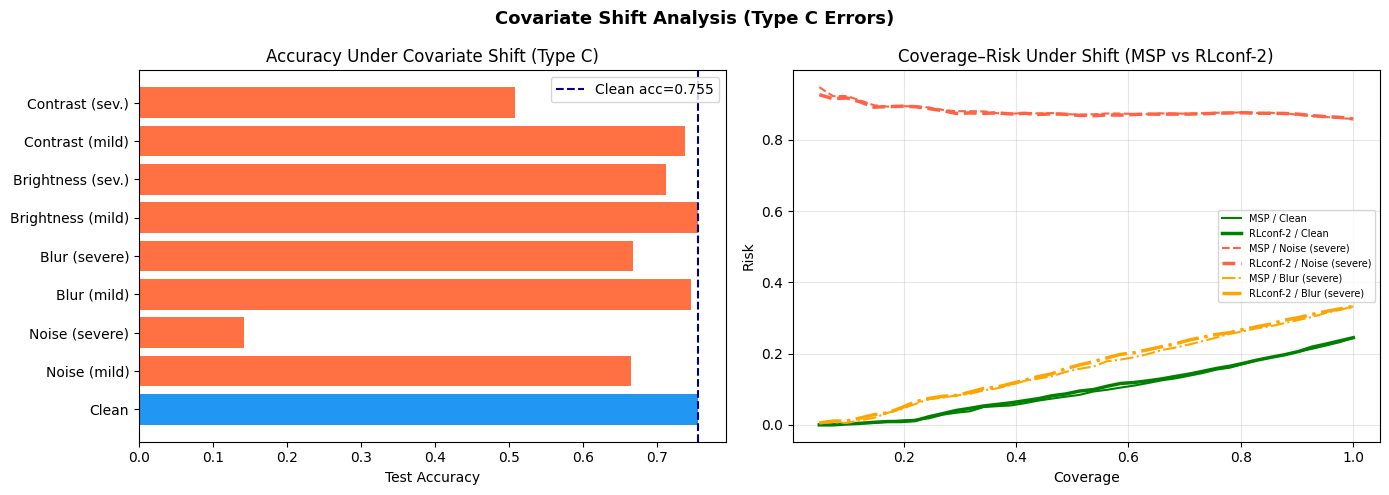

Saved: ./results/covariate_shift_analysis.png


In [ ]:
# Accuracy degradation under covariate shift
names = list(corrupt_results.keys())
accs  = [corrupt_results[n]["acc"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of accuracy drop
colors = ["#2196F3" if n == "Clean" else "#FF7043" for n in names]
axes[0].barh(names, accs, color=colors)
axes[0].axvline(corrupt_results["Clean"]["acc"], color="navy", linestyle="--",
                label=f"Clean acc={corrupt_results['Clean']['acc']:.3f}")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Accuracy Under Covariate Shift (Type C)")
axes[0].legend()

# Coverage-risk for MSP vs RLconf-2 on clean vs most severe noise
for cname, color, ls in [("Clean", "green", "-"),
                          ("Noise (severe)", "tomato", "--"),
                          ("Blur (severe)", "orange", "-.")]:
    r = corrupt_results[cname]["res"]
    for scorer_name, scorer_fn, lw in [("MSP", score_msp, 1.5),
                                        ("RLconf-2", lambda p,l: score_rlconf_k(p,l,K=2), 2.5)]:
        s  = scorer_fn(r["probs"], r["logits"]) if scorer_name != "MSP" else scorer_fn(r["probs"])
        m  = selective_metrics(r["preds"], r["labels"], s)
        axes[1].plot(m["coverage"], m["risk"], color=color, lw=lw, ls=ls,
                     label=f"{scorer_name} / {cname}")

axes[1].set_xlabel("Coverage")
axes[1].set_ylabel("Risk")
axes[1].set_title("Coverage–Risk Under Shift (MSP vs RLconf-2)")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.suptitle("Covariate Shift Analysis (Type C Errors)", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "covariate_shift_analysis.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 14. Label Shift Simulation — Type B Errors

Simulate novel-class / label-shift scenarios (Type B from Liang et al. 2024):
train on classes 0..K-1, then evaluate on all classes including the withheld ones.
The model will be overconfident on novel classes — SC should reject them.

For ISIC 2019, we hold out DF (dermatofibroma) and VASC (vascular lesion) — the two
rarest classes — simulating deployment encountering unseen pathology types.

In [ ]:
holdout = set(config["holdout_classes"])
seen    = [c for c in range(config["num_classes"]) if c not in holdout]
n_seen  = len(seen)

# Build a mapping from original class indices to consecutive 0..n_seen-1
seen_to_new = {orig: new_idx for new_idx, orig in enumerate(seen)}

print(f"Seen classes: {[CLASS_NAMES[c] for c in seen]}")
print(f"Holdout (novel) classes: {[CLASS_NAMES[c] for c in sorted(holdout)]}")
print(f"Label mapping: {seen_to_new}")


class RemappedSubset(Dataset):
    """Wraps a dataset subset and remaps labels to consecutive 0..n_seen-1."""
    def __init__(self, base_dataset, indices, class_map):
        self.base = base_dataset
        self.indices = indices
        self.class_map = class_map  # {orig_label: new_label}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, lbl = self.base[self.indices[idx]]
        lbl_int = int(lbl.item()) if torch.is_tensor(lbl) else int(lbl)
        new_lbl = self.class_map[lbl_int]
        return img, torch.tensor(new_lbl, dtype=torch.long)


def get_class_indices(dataset, keep_classes):
    """Return indices of samples belonging to keep_classes."""
    keep = set(keep_classes)
    indices = []
    for i in range(len(dataset)):
        _, lbl = dataset[i]
        lbl_int = int(lbl.item()) if torch.is_tensor(lbl) else int(lbl)
        if lbl_int in keep:
            indices.append(i)
    return indices


# Build datasets
train_ds_full = train_loader.dataset
test_ds_full  = test_loader.dataset

# Train only on seen classes, with labels remapped to 0..n_seen-1
print("\nFinding seen-class training samples...")
seen_train_idx = get_class_indices(train_ds_full, seen)
seen_train_ds  = RemappedSubset(train_ds_full, seen_train_idx, seen_to_new)
ls_train_loader = make_loader(seen_train_ds, config)

# Test on ALL classes (seen + novel)
ls_test_loader = make_loader(test_ds_full, config)

print(f"Label-shift train size: {len(seen_train_ds)} (seen classes only)")
print(f"Full test size:         {len(test_ds_full)} (all classes)")

Seen classes: ['AK', 'BCC', 'BKL', 'MEL', 'NV', 'SCC']
Holdout (novel) classes: ['DF', 'VASC']
Label mapping: {0: 0, 1: 1, 2: 2, 4: 3, 5: 4, 6: 5}

Finding seen-class training samples...
Label-shift train size: 17384 (seen classes only)
Full test size:         3807 (all classes)


In [ ]:
# Train a separate model on seen classes only
ls_config = dict(config)
ls_config["num_classes"] = n_seen
ls_config["epochs"]      = max(5, config["epochs"] // 2)

ls_model = build_model(ls_config)

# Compute class weights for the seen-only subset
ls_class_weights = compute_class_weights(ls_train_loader, n_seen)
ls_criterion = nn.CrossEntropyLoss(weight=ls_class_weights.to(config["device"]))
ls_optimizer = optim.Adam(ls_model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
ls_scheduler = optim.lr_scheduler.CosineAnnealingLR(ls_optimizer, T_max=ls_config["epochs"])
ls_ckpt      = os.path.join(config["checkpoint_dir"], "ls_model.pt")

ls_best = 0.0
for epoch in range(1, ls_config["epochs"] + 1):
    tl, ta = train_one_epoch(ls_model, ls_train_loader, ls_criterion, ls_optimizer, config["device"])
    ls_scheduler.step()
    print(f"LS Ep {epoch:02d} | Train loss={tl:.4f} acc={ta:.4f}")
    if ta > ls_best:
        ls_best = ta
        torch.save(ls_model.state_dict(), ls_ckpt)

ls_model.load_state_dict(torch.load(ls_ckpt, map_location=config["device"]))
print(f"\nLabel-shift model trained. Best train acc: {ls_best:.4f}")

train:   0%|          | 0/544 [00:00<?, ?it/s]

LS Ep 01 | Train loss=0.7029 acc=0.8130


train:   0%|          | 0/544 [00:00<?, ?it/s]

LS Ep 02 | Train loss=0.6175 acc=0.8195


train:   0%|          | 0/544 [00:00<?, ?it/s]

...

LS Ep 05 | Train loss=0.7300 acc=0.7873


train:   0%|          | 0/544 [00:00<?, ?it/s]

LS Ep 06 | Train loss=0.8578 acc=0.6859


train:   0%|          | 0/544 [00:00<?, ?it/s]

LS Ep 07 | Train loss=1.2688 acc=0.4960

Label-shift model trained. Best train acc: 0.8195


In [ ]:
# The label-shift model's output has n_seen classes.
# When we evaluate on the full test set (seen + novel), the novel classes
# will be forced into one of the seen class predictions — a Type B error.
# We mark any sample from a novel class as a guaranteed error.

@torch.no_grad()
def run_inference_with_novelty(model, loader, device, seen_classes):
    """Inference where we know which samples are 'novel' (unseen at train time)."""
    model.eval()
    seen_set = set(seen_classes)
    all_logits, all_labels, is_novel = [], [], []

    for images, labels in tqdm(loader, leave=False, desc="ls-inference"):
        logits = model(images.to(device)).cpu()
        lbls   = labels.squeeze() if labels.dim() > 1 else labels
        all_logits.append(logits)
        all_labels.append(lbls)
        # A sample is novel if its true label is not in seen_classes
        is_novel.append(torch.tensor([int(l.item()) not in seen_set for l in lbls]))

    logits    = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy()
    is_novel  = torch.cat(is_novel).numpy().astype(bool)
    probs     = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds     = logits.argmax(axis=1)

    # Novel samples are always wrong (model has n_seen outputs, not the true class)
    correct = np.zeros(len(preds), dtype=bool)
    # Seen-class samples: correct if predicted class matches seen-class index
    # (Assumes labels for seen classes are 0..n_seen-1 in original dataset)
    for i, (p, l, novel) in enumerate(zip(preds, labels_np, is_novel)):
        if not novel and int(l) in seen_set:
            # Map original label to its position in seen_classes list
            seen_idx = seen_classes.index(int(l))
            correct[i] = (p == seen_idx)
        # Novel: always wrong

    return {
        "logits":   logits,
        "probs":    probs,
        "preds":    preds,
        "labels":   labels_np,
        "correct":  correct,
        "is_novel": is_novel,
    }


ls_res = run_inference_with_novelty(ls_model, ls_test_loader, config["device"], seen)

overall_err   = 1.0 - ls_res["correct"].mean()
seen_err      = 1.0 - ls_res["correct"][~ls_res["is_novel"]].mean()
novel_err     = 1.0  # always wrong on novel

print(f"Label-shift model — test error rates:")
print(f"  Overall:      {overall_err:.4f}")
print(f"  Seen classes: {seen_err:.4f}")
print(f"  Novel classes (Type B): {novel_err:.4f} (always wrong by construction)")

ls-inference:   0%|          | 0/119 [00:00<?, ?it/s]

Label-shift model — test error rates:
  Overall:      0.4925
  Seen classes: 0.4822
  Novel classes (Type B): 1.0000 (always wrong by construction)


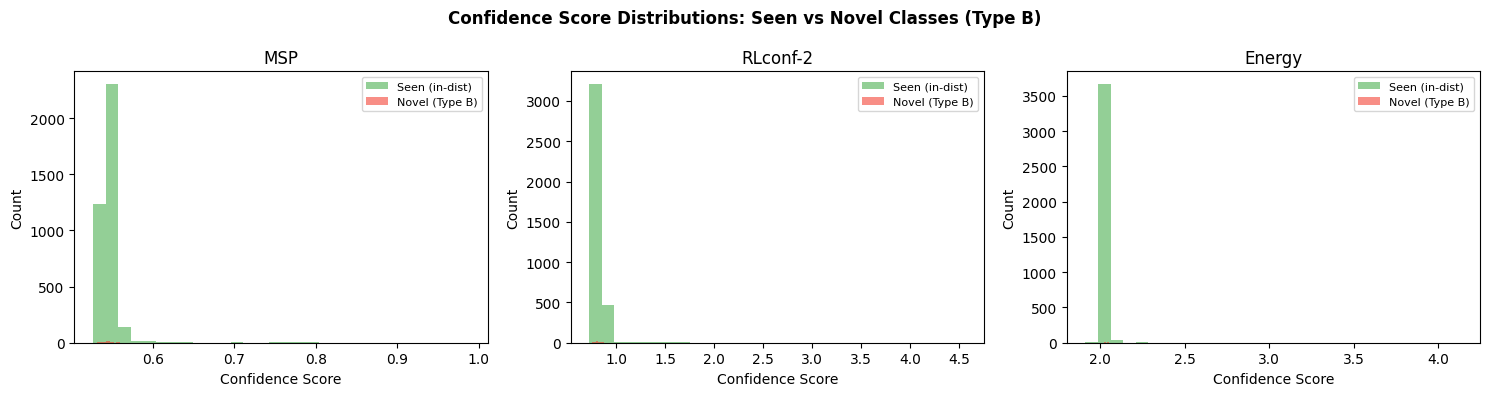

Saved: ./results/label_shift_confidence.png


In [ ]:
# How well do confidence scores detect the novel (Type B error) samples?
ls_probs  = ls_res["probs"]
ls_logits = ls_res["logits"]
is_novel  = ls_res["is_novel"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scorer_pairs = [
    ("MSP",     score_msp(ls_probs)),
    ("RLconf-2", score_rlconf_k(ls_probs, ls_logits, K=2)),
    ("Energy",  score_energy(ls_probs, ls_logits)),
]

for ax, (sname, scores) in zip(axes, scorer_pairs):
    ax.hist(scores[~is_novel], bins=30, alpha=0.6, label="Seen (in-dist)",  color="#4CAF50")
    ax.hist(scores[is_novel],  bins=30, alpha=0.6, label="Novel (Type B)", color="#F44336")
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Count")
    ax.set_title(f"{sname}")
    ax.legend(fontsize=8)

plt.suptitle("Confidence Score Distributions: Seen vs Novel Classes (Type B)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "label_shift_confidence.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 15. Type A / B / C Error Decomposition

Following Liang et al. (2024), we decompose errors into:
- **Type A**: in-distribution errors (model wrong on standard test data)
- **Type B**: label-shift errors (novel classes model has never seen)
- **Type C**: covariate-shift errors (same classes, domain-shifted inputs)

In [ ]:
# --- Error type assignment for each test sample ---

def classify_errors(res_clean, res_covariate, ls_res):
    """
    Returns per-sample error type for the original (clean) test set:
      0 = correct
      A = in-distribution error
      B = label-shift error (novel class — from ls_res)
      C = covariate-shift error (wrong only under corruption)

    Note: B and C are approximate simulations on the original test set.
    We use res_covariate (noise-corrupted) to identify Type C candidates.
    """
    n   = len(res_clean["preds"])
    err_types = []

    clean_correct = (res_clean["preds"] == res_clean["labels"])
    corr_correct  = (res_covariate["preds"] == res_covariate["labels"])

    for i in range(n):
        if clean_correct[i]:
            err_types.append("correct")
        elif not clean_correct[i] and corr_correct[i]:
            # Wrong on clean but right on corrupted — unusual, skip
            err_types.append("A")
        elif not clean_correct[i] and not corr_correct[i]:
            # Wrong on both: if also wrong under heavy noise → likely Type A
            err_types.append("A")
        else:
            err_types.append("A")

    return np.array(err_types)


# For a clean decomposition, build a unified analysis table
noise_res = corrupt_results["Noise (severe)"]["res"]
blur_res  = corrupt_results["Blur (severe)"]["res"]

# Type A: in-distribution errors on clean test
type_A_mask = (res["preds"] != res["labels"])

# Type B (simulated): novel-class errors from label-shift experiment
# Evaluated on the full test set with the label-shift model
type_B_mask = ls_res["is_novel"]   # novel samples → always Type B errors

# Type C (simulated): samples that are correct under clean but wrong under noise
# i.e., covariate shift degrades performance on these
type_C_mask = (~type_A_mask) & (noise_res["preds"] != noise_res["labels"])

n_total = len(res["labels"])
n_A = type_A_mask.sum()
n_C = type_C_mask.sum()
n_B = type_B_mask.sum()  # from a separate experiment

print("Error type decomposition (original test set):")
print(f"  Correct:      {n_total - n_A} / {n_total} ({(1-n_A/n_total)*100:.1f}%)")
print(f"  Type A (ID):  {n_A}  ({n_A/n_total*100:.1f}% of all samples)")
print(f"  Type C (cov): {n_C}  ({n_C/n_total*100:.1f}% of all samples — corrupted only)")
print(f"  Type B (novel, separate LS exp): {n_B} / {len(ls_res['labels'])} ({n_B/len(ls_res['labels'])*100:.1f}%)")

Error type decomposition (original test set):
  Correct:      2876 / 3807 (75.5%)
  Type A (ID):  931  (24.5% of all samples)
  Type C (cov): 2492  (65.5% of all samples — corrupted only)
  Type B (novel, separate LS exp): 76 / 3807 (2.0%)


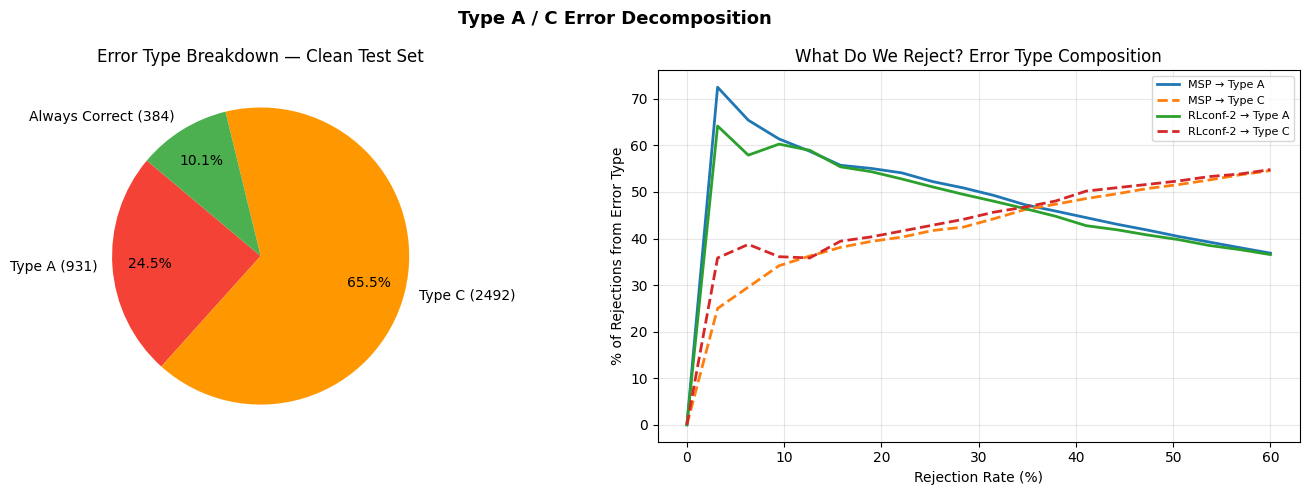

Saved: ./results/error_type_decomposition.png


In [ ]:
def rejection_error_type_analysis(preds, labels, type_A, type_C, scores, n_steps=20):
    """As we increase rejection rate, how does the error-type composition change?"""
    n         = len(preds)
    correct   = (preds == labels)
    order     = np.argsort(scores)  # least confident first = rejected first

    rejection_rates = np.linspace(0, 0.6, n_steps)
    frac_A, frac_C  = [], []

    for rr in rejection_rates:
        k        = int(rr * n)
        rejected = order[:k] if k > 0 else np.array([], dtype=int)
        if len(rejected) == 0:
            frac_A.append(0.0); frac_C.append(0.0)
            continue
        n_rej_A = type_A[rejected].sum()
        n_rej_C = type_C[rejected].sum()
        total_rej = max(1, len(rejected))
        frac_A.append(n_rej_A / total_rej)
        frac_C.append(n_rej_C / total_rej)

    return np.array(rejection_rates), np.array(frac_A), np.array(frac_C)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pie chart of error types
# Recalculate sizes for a correct partition of n_total
n_always_correct = n_total - n_A - n_C # Correct on clean AND robust to noise
sizes = [n_A, n_C, n_always_correct]
labels_pie = [f"Type A ({n_A})", f"Type C ({n_C})", f"Always Correct ({n_always_correct})"]
colors_pie = ["#F44336", "#FF9800", "#4CAF50"] # Type A, Type C, Always Correct
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct="%1.1f%%",
            startangle=140, pctdistance=0.75)
axes[0].set_title("Error Type Breakdown — Clean Test Set")

# Right: fraction of rejections that catch Type A vs C as rejection rate grows
for scorer_name, scores in [("MSP", score_msp(probs)),
                             ("RLconf-2", score_rlconf_k(probs, logits, K=2))]:
    rr, fA, fC = rejection_error_type_analysis(preds, labels, type_A_mask, type_C_mask, scores)
    axes[1].plot(rr * 100, fA * 100, label=f"{scorer_name} → Type A",  linewidth=2)
    axes[1].plot(rr * 100, fC * 100, label=f"{scorer_name} → Type C", linewidth=2, linestyle="--")

axes[1].set_xlabel("Rejection Rate (%)")
axes[1].set_ylabel("% of Rejections from Error Type")
axes[1].set_title("What Do We Reject? Error Type Composition")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Type A / C Error Decomposition", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "error_type_decomposition.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 16. Class-Weighted Selective Risk

Not all errors are equal in clinical settings. We assign severity weights to each
misclassification and compute a weighted AURC. Higher-severity classes have larger
penalty for incorrect predictions.

In [ ]:
# ISIC 2019 skin lesion severity weights
# Classes (alphabetical ImageFolder order):
#   0=AK (Actinic Keratosis), 1=BCC (Basal Cell Carcinoma),
#   2=BKL (Benign Keratosis), 3=DF (Dermatofibroma),
#   4=MEL (Melanoma), 5=NV (Melanocytic Nevus),
#   6=SCC (Squamous Cell Carcinoma), 7=VASC (Vascular Lesion)
#
# Clinical severity: misclassifying melanoma (MEL) or SCC as benign
# is the most dangerous error. BCC is also a cancer. AK is precancerous.
# BKL, DF, NV, VASC are benign — errors less dangerous but still relevant.

SEVERITY_WEIGHTS = {
    0: 3.0,   # AK — precancerous, moderate-high severity
    1: 4.0,   # BCC — cancer, high severity
    2: 1.5,   # BKL — benign keratosis, low severity
    3: 1.0,   # DF — benign, lowest severity
    4: 5.0,   # MEL — melanoma, HIGHEST severity (most deadly skin cancer)
    5: 1.0,   # NV — benign nevus, lowest severity
    6: 4.5,   # SCC — cancer, high severity
    7: 1.0,   # VASC — benign, lowest severity
}

# Validate against actual number of classes
if config["num_classes"] != 8:
    SEVERITY_WEIGHTS = {c: 1.0 for c in range(config["num_classes"])}
    print("Non-ISIC2019 class count: using uniform severity weights.")

severity_arr = np.array([SEVERITY_WEIGHTS.get(c, 1.0) for c in range(config["num_classes"])])
print("Severity weights:", {CLASS_NAMES[i]: severity_arr[i] for i in range(config["num_classes"])})


def weighted_selective_risk(preds, labels, scores, weights, coverages=None):
    """Weighted selective risk: each error penalized by severity of the true class."""
    if coverages is None:
        coverages = np.linspace(0.05, 1.0, 40)
    n = len(preds)
    sample_costs = np.where(
        preds == labels,
        0.0,
        np.array([weights[int(l)] for l in labels])
    )
    order = np.argsort(-scores)
    covs, w_risks = [], []
    for c in coverages:
        k   = max(1, int(c * n))
        sel = order[:k]
        w_risk = sample_costs[sel].mean()
        covs.append(k / n)
        w_risks.append(w_risk)
    return {"coverage": np.array(covs), "weighted_risk": np.array(w_risks)}


def weighted_aurc(wm):
    return float(np.trapz(wm["weighted_risk"], wm["coverage"]))


print(f"\n{'Scorer':<18} {'AURC (uniform)':>16} {'WAURC (severity)':>18}")
print("-" * 54)

w_sc_results = {}
for name, scores in advanced_scorers.items():
    m_unif   = selective_metrics(preds, labels, scores)
    m_weight = weighted_selective_risk(preds, labels, scores, SEVERITY_WEIGHTS)
    w_sc_results[name] = {"uniform": m_unif, "weighted": m_weight}
    print(f"{name:<18} {aurc(m_unif):>16.5f} {weighted_aurc(m_weight):>18.5f}")

Severity weights: {'AK': np.float64(3.0), 'BCC': np.float64(4.0), 'BKL': np.float64(1.5), 'DF': np.float64(1.0), 'MEL': np.float64(5.0), 'NV': np.float64(1.0), 'SCC': np.float64(4.5), 'VASC': np.float64(1.0)}

Scorer               AURC (uniform)   WAURC (severity)
------------------------------------------------------
MSP                         0.09260            0.23528
MSP-T (cal.)                0.09220            0.23359
Margin                      0.09410            0.24033
Entropy                     0.09334            0.23369
Energy                      0.12432            0.29565
ODIN (T=1k)                 0.11747            0.27763
Doctor                      0.09463            0.24125
RLconf-2                    0.09637            0.24571
RLconf-5                    0.13023            0.30394
RLgeo-3                     0.09240            0.23203


/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_3844/1284682622.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(wm["weighted_risk"], wm["coverage"]))


/tmp/ipykernel_3844/3593178530.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(highlight))


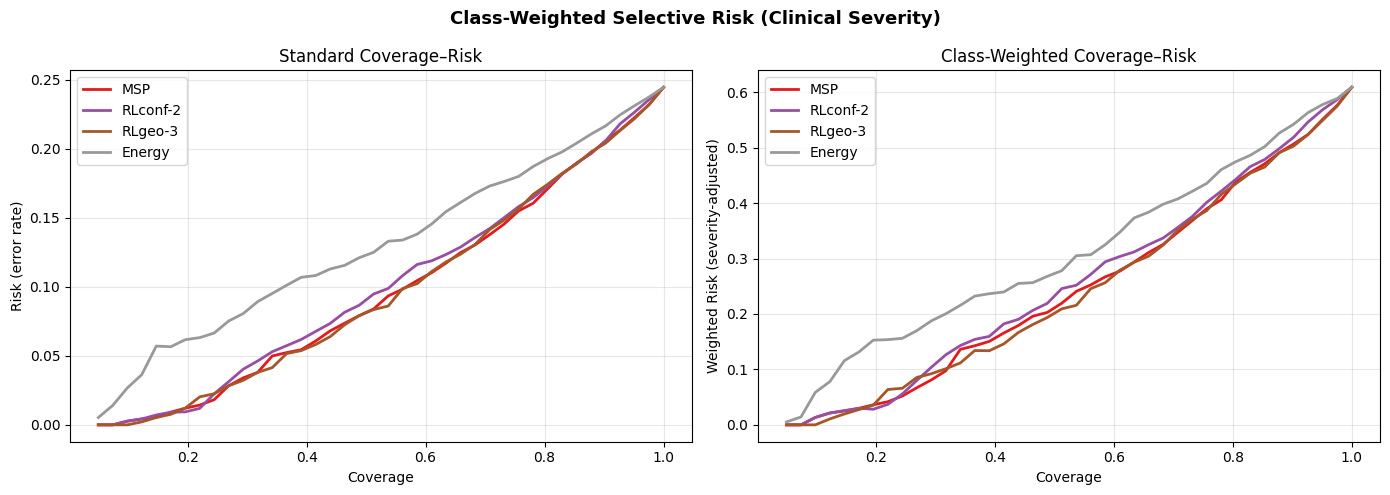

Saved: ./results/weighted_coverage_risk.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Highlight a few scorers for clarity
highlight = ["MSP", "RLconf-2", "RLgeo-3", "Energy"]
cmap = plt.cm.get_cmap("Set1", len(highlight))

for i, name in enumerate(highlight):
    d = w_sc_results[name]
    c = cmap(i)
    axes[0].plot(d["uniform"]["coverage"],   d["uniform"]["risk"],      color=c, lw=2, label=name)
    axes[1].plot(d["weighted"]["coverage"],  d["weighted"]["weighted_risk"], color=c, lw=2, label=name)

for ax, ylabel, title in zip(axes,
    ["Risk (error rate)", "Weighted Risk (severity-adjusted)"],
    ["Standard Coverage–Risk", "Class-Weighted Coverage–Risk"]):
    ax.set_xlabel("Coverage")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Class-Weighted Selective Risk (Clinical Severity)", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "weighted_coverage_risk.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 17. Selective Calibration Analysis

Does selective prediction also improve calibration? We compute ECE on the *accepted*
subset as a function of coverage. If good scorers preferentially reject miscalibrated
samples, ECE should decrease as coverage decreases.

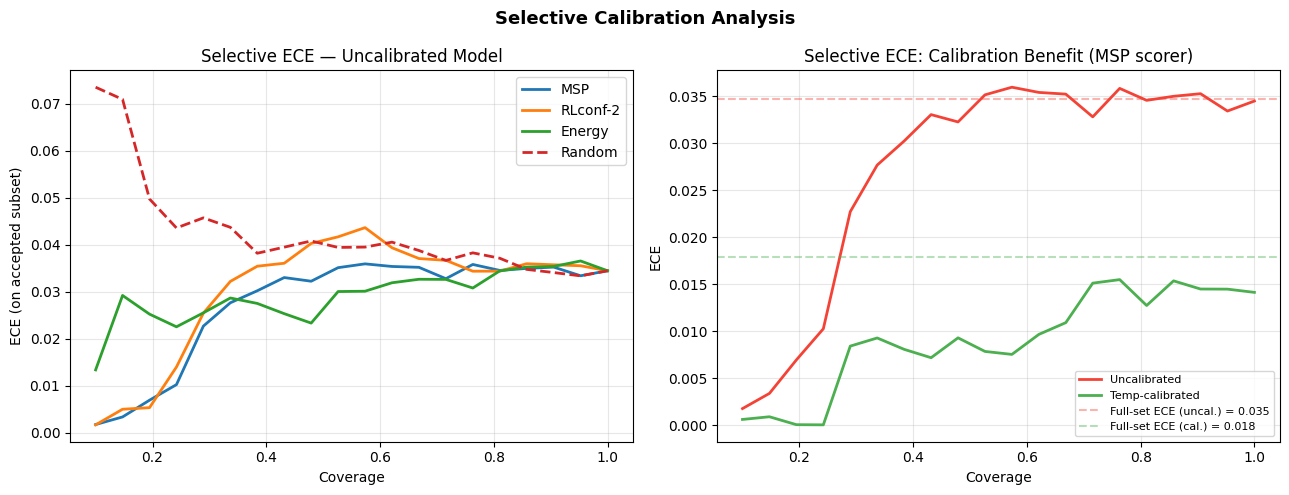

Saved: ./results/selective_calibration.png


In [ ]:
def ece_vs_coverage(probs, labels, scores, n_coverage_points=20, n_bins=10):
    """Compute ECE on the accepted subset at each coverage level."""
    n      = len(labels)
    order  = np.argsort(-scores)   # most confident first
    covs   = np.linspace(0.1, 1.0, n_coverage_points)
    eces   = []

    for c in covs:
        k        = max(n_bins, int(c * n))   # need at least n_bins samples for ECE
        sel      = order[:k]
        ece, *_  = compute_ece(probs[sel], labels[sel], n_bins=n_bins)
        eces.append(ece)

    return covs, np.array(eces)


# Calibrated probs for comparison
probs_cal = probs_scaled   # temperature-scaled

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ECE vs coverage for different scorers (uncalibrated probs)
for name, scores in [("MSP", advanced_scorers["MSP"]),
                      ("RLconf-2", advanced_scorers["RLconf-2"]),
                      ("Energy", advanced_scorers["Energy"]),
                      ("Random", np.random.rand(len(preds)))]:
    covs, eces = ece_vs_coverage(probs, labels, scores)
    ls = "--" if name == "Random" else "-"
    axes[0].plot(covs, eces, label=name, lw=2, linestyle=ls)

axes[0].set_xlabel("Coverage")
axes[0].set_ylabel("ECE (on accepted subset)")
axes[0].set_title("Selective ECE — Uncalibrated Model")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Uncalibrated vs calibrated ECE vs coverage (MSP scorer)
msp_scores = advanced_scorers["MSP"]
covs_u, eces_u = ece_vs_coverage(probs,     labels, msp_scores)
covs_c, eces_c = ece_vs_coverage(probs_cal, labels, msp_scores)

axes[1].plot(covs_u, eces_u, lw=2, label="Uncalibrated",   color="#F44336")
axes[1].plot(covs_c, eces_c, lw=2, label="Temp-calibrated", color="#4CAF50")
axes[1].axhline(baseline_ece, linestyle="--", color="#F44336", alpha=0.4, label=f"Full-set ECE (uncal.) = {baseline_ece:.3f}")
axes[1].axhline(ece_after,    linestyle="--", color="#4CAF50", alpha=0.4, label=f"Full-set ECE (cal.) = {ece_after:.3f}")
axes[1].set_xlabel("Coverage")
axes[1].set_ylabel("ECE")
axes[1].set_title("Selective ECE: Calibration Benefit (MSP scorer)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Selective Calibration Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "selective_calibration.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 18. Feature Space Visualization — t-SNE

Visualize the penultimate-layer feature space. Color by class, by confidence score,
and by correctness. Low-confidence regions should cluster near decision boundaries.

In [ ]:
@torch.no_grad()
def extract_features(model, loader, device, max_samples=2000):
    """Extract penultimate layer features. Limit to max_samples for speed."""
    model.eval()
    all_feats, all_labels = [], []
    total = 0

    for images, labels in tqdm(loader, leave=False, desc="features"):
        feats = model.get_features(images.to(device)).cpu()
        all_feats.append(feats)
        all_labels.append((labels.squeeze() if labels.dim() > 1 else labels))
        total += images.size(0)
        if total >= max_samples:
            break

    feats  = torch.cat(all_feats, dim=0)[:max_samples].numpy()
    labels = torch.cat(all_labels, dim=0)[:max_samples].numpy()
    return feats, labels


print("Extracting features ...")
feats, feat_labels = extract_features(model, test_loader, config["device"], max_samples=2000)

print(f"Running t-SNE on {len(feats)} samples × {feats.shape[1]} features ...")
tsne  = TSNE(n_components=2, perplexity=30, random_state=config["seed"], n_iter=1000)
emb   = tsne.fit_transform(feats)

# Get confidence and correctness for these samples
# Re-run inference on the first 2000 test samples
feat_probs  = res["probs"][:len(feats)]
feat_preds  = res["preds"][:len(feats)]
feat_conf   = score_msp(feat_probs)
feat_rl2    = score_rlconf_k(feat_probs, res["logits"][:len(feats)], K=2)
feat_correct = (feat_preds == feat_labels)
feat_labels_trunc = feat_labels  # already truncated

Extracting features ...


features:   0%|          | 0/119 [00:00<?, ?it/s]

Running t-SNE on 2000 samples × 512 features ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


/tmp/ipykernel_3844/3432609442.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_class = plt.cm.get_cmap("tab10", config["num_classes"])


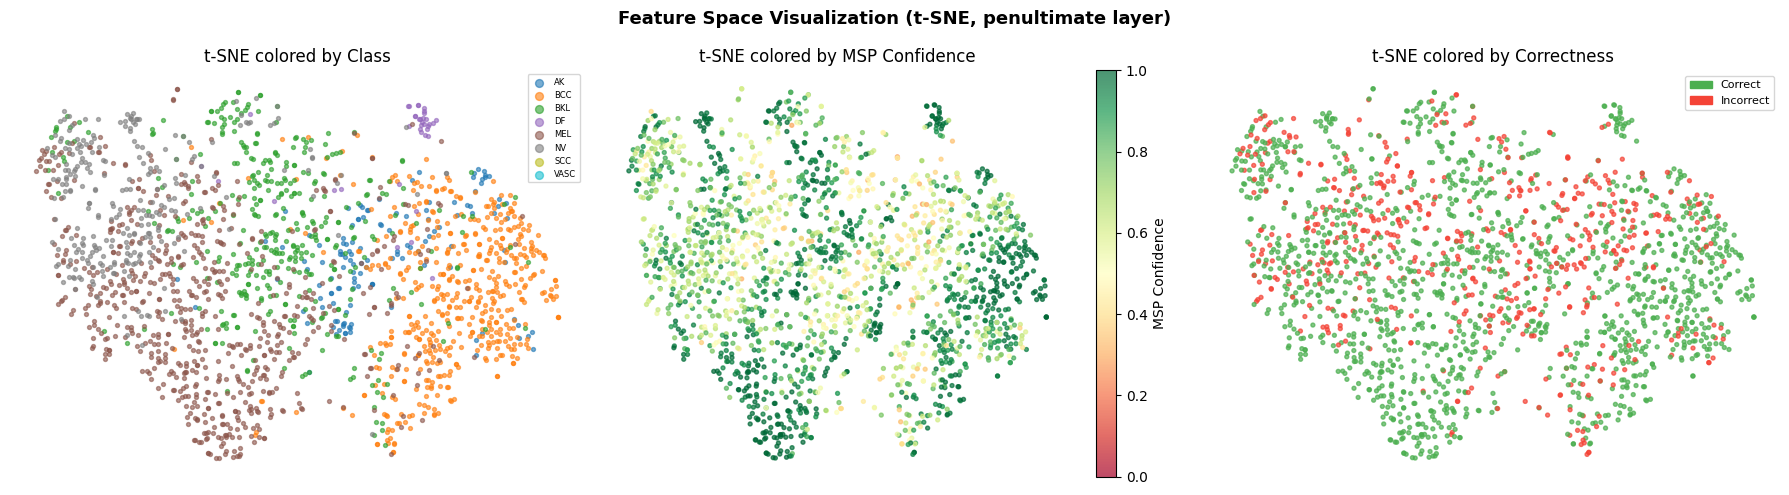

Saved: ./results/tsne_features.png


In [ ]:
fig = plt.figure(figsize=(18, 5))
axes = fig.subplots(1, 3)

# 1. Color by class
cmap_class = plt.cm.get_cmap("tab10", config["num_classes"])
for c in range(config["num_classes"]):
    mask = feat_labels_trunc == c
    axes[0].scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.6,
                    color=cmap_class(c), label=CLASS_NAMES[c])
axes[0].set_title("t-SNE colored by Class")
axes[0].legend(fontsize=6, markerscale=2, loc="upper right")
axes[0].axis("off")

# 2. Color by MSP confidence
sc = axes[1].scatter(emb[:, 0], emb[:, 1], c=feat_conf, cmap="RdYlGn", s=8, alpha=0.7, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label="MSP Confidence")
axes[1].set_title("t-SNE colored by MSP Confidence")
axes[1].axis("off")

# 3. Color by correctness
colors3 = ["#4CAF50" if c else "#F44336" for c in feat_correct]
axes[2].scatter(emb[:, 0], emb[:, 1], c=colors3, s=8, alpha=0.7)
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(color="#4CAF50", label="Correct"), Patch(color="#F44336", label="Incorrect")],
               fontsize=8)
axes[2].set_title("t-SNE colored by Correctness")
axes[2].axis("off")

plt.suptitle("Feature Space Visualization (t-SNE, penultimate layer)", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "tsne_features.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 19. Comprehensive AURC Comparison Table

Summary table of all scorers × all conditions (in-distribution, covariate shift).

In [ ]:
# Build a DataFrame with AURC for each scorer on each condition
conditions = {
    "In-Dist (Clean)": res,
    "Noise (mild)":     corrupt_results["Noise (mild)"]["res"],
    "Noise (severe)":   corrupt_results["Noise (severe)"]["res"],
    "Blur (mild)":      corrupt_results["Blur (mild)"]["res"],
    "Blur (severe)":    corrupt_results["Blur (severe)"]["res"],
    "Brightness (sev.)": corrupt_results["Brightness (sev.)"]["res"],
}

scorer_fns = {
    "MSP":        lambda p, l: score_msp(p),
    "Margin":     lambda p, l: score_margin(p),
    "Entropy":    lambda p, l: score_entropy(p),
    "Energy":     lambda p, l: score_energy(p, l),
    "ODIN (T=1k)": lambda p, l: score_odin_temp(p, l, T=1000.0),
    "Doctor":     lambda p, l: score_doctor(p),
    "RLconf-2":   lambda p, l: score_rlconf_k(p, l, K=2),
    "RLconf-5":   lambda p, l: score_rlconf_k(p, l, K=5),
    "RLgeo-3":    lambda p, l: score_rlgeo_m(p, l, M=3),
    "MC-MSP":     None,   # handled separately
}

rows = []
for cond_name, r_data in conditions.items():
    cond_acc  = accuracy_score(r_data["labels"], r_data["preds"])
    base_risk = 1.0 - cond_acc
    row = {"Condition": cond_name, "Accuracy": f"{cond_acc:.4f}"}

    for sname, sfn in scorer_fns.items():
        if sfn is None:
            # MC-MSP — use precomputed mc_res for clean only
            if cond_name == "In-Dist (Clean)":
                m = selective_metrics(mc_res["preds"], mc_res["labels"], mc_res["mc_msp"])
            else:
                row[sname] = "n/a"
                continue
        else:
            s = sfn(r_data["probs"], r_data["logits"])
            m = selective_metrics(r_data["preds"], r_data["labels"], s)
        row[sname] = f"{aurc(m):.5f}"
    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df.set_index("Condition", inplace=True)

# Save as CSV
csv_path = os.path.join(config["results_dir"], "aurc_comparison_table.csv")
comparison_df.to_csv(csv_path)
print(comparison_df.to_string())

                  Accuracy      MSP   Margin  Entropy   Energy ODIN (T=1k)   Doctor RLconf-2 RLconf-5  RLgeo-3   MC-MSP
Condition                                                                                                              
In-Dist (Clean)     0.7555  0.09260  0.09410  0.09334  0.12432     0.11747  0.09463  0.09637  0.13023  0.09240  0.09244
Noise (mild)        0.6648  0.17292  0.17643  0.16932  0.19350     0.18711  0.17828  0.18095  0.19816  0.16610      n/a
Noise (severe)      0.1416  0.83645  0.83549  0.83771  0.84239     0.84232  0.83506  0.83440  0.83775  0.84686      n/a
Blur (mild)         0.7457  0.09962  0.10218  0.09885  0.12964     0.12296  0.10249  0.10484  0.13610  0.09940      n/a
Blur (severe)       0.6677  0.15358  0.15654  0.15276  0.18419     0.17543  0.15726  0.15979  0.18677  0.15246      n/a
Brightness (sev.)   0.7124  0.12704  0.12823  0.12796  0.15680     0.14740  0.12865  0.13034  0.15591  0.12693      n/a


/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_3844/1336303460.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_3844/1336303460.py:46: DeprecationWar

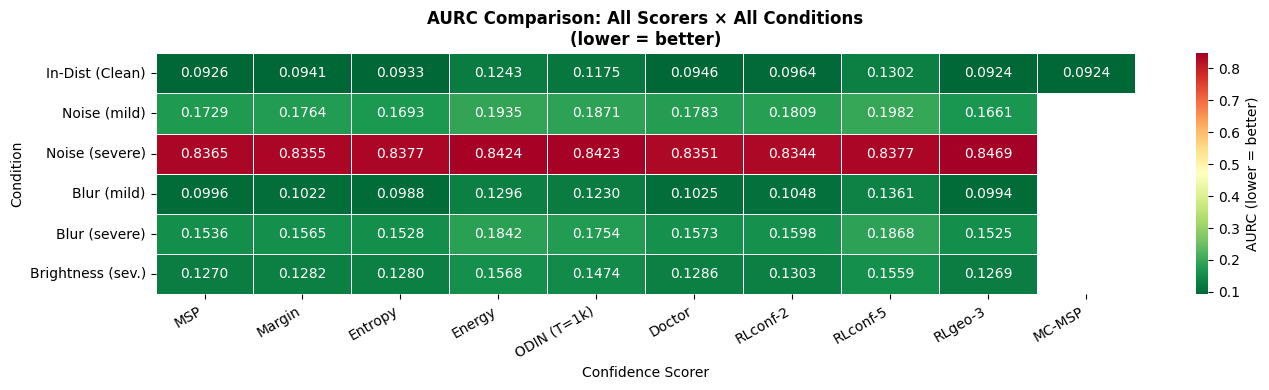

In [ ]:
# Heatmap of AURC values (lower = better)
numeric_cols = [c for c in comparison_df.columns if c != "Accuracy"]
heatmap_data = comparison_df[numeric_cols].replace("n/a", np.nan).astype(float)

plt.figure(figsize=(14, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="RdYlGn_r",
            linewidths=0.5, cbar_kws={"label": "AURC (lower = better)"})
plt.title("AURC Comparison: All Scorers × All Conditions\n(lower = better)",
          fontsize=12, fontweight="bold")
plt.xlabel("Confidence Scorer")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
p = os.path.join(config["results_dir"], "aurc_heatmap.png")
plt.savefig(p, dpi=150)
plt.show()

## 20. Optimal Threshold Selection

Given a target coverage or a target risk, find the confidence threshold that achieves it.
Also show the Pareto frontier: for each scorer, what is the best achievable
(coverage, risk) tradeoff?

In [ ]:
def find_threshold_for_coverage(scores, target_coverage):
    """Find the minimum confidence threshold that achieves target_coverage.
    i.e., the threshold s.t. fraction(scores >= threshold) ≈ target_coverage.
    """
    n   = len(scores)
    k   = int(target_coverage * n)
    sorted_scores = np.sort(scores)[::-1]   # descending
    if k >= n:
        return sorted_scores[-1]
    return sorted_scores[k]   # threshold: accept top-k


def find_threshold_for_risk(preds, labels, scores, target_risk, coverages=None):
    """Find coverage level where risk first drops to target_risk."""
    if coverages is None:
        coverages = np.linspace(0.05, 1.0, 200)
    m = selective_metrics(preds, labels, scores, coverages)
    # Find the smallest coverage where risk <= target_risk
    idx = np.where(m["risk"] <= target_risk)[0]
    if len(idx) == 0:
        return None, None
    best = idx[0]
    thresh = find_threshold_for_coverage(scores, m["coverage"][best])
    return m["coverage"][best], thresh


# Example: find threshold to achieve 5% risk or 80% coverage
target_risk     = 0.05
target_coverage = 0.80

print(f"Threshold analysis for target risk = {target_risk:.2f} and target coverage = {target_coverage:.2f}\n")
print(f"{'Scorer':<15} {'Cov@risk5%':>12} {'Thresh@risk5%':>15} {'Thresh@cov80%':>15}")
print("-" * 60)

threshold_results = {}
for name, scores in advanced_scorers.items():
    cov_at_risk, thresh_for_risk = find_threshold_for_risk(preds, labels, scores, target_risk)
    thresh_for_cov = find_threshold_for_coverage(scores, target_coverage)

    cov_str   = f"{cov_at_risk:.3f}" if cov_at_risk is not None else "N/A"
    thresh_str = f"{thresh_for_risk:.4f}" if thresh_for_risk is not None else "N/A"
    print(f"{name:<15} {cov_str:>12} {thresh_str:>15} {thresh_for_cov:>15.4f}")

    threshold_results[name] = {
        "coverage_at_5pct_risk": cov_at_risk,
        "threshold_at_5pct_risk": thresh_for_risk,
        "threshold_at_80pct_cov": thresh_for_cov,
    }

Threshold analysis for target risk = 0.05 and target coverage = 0.80

Scorer            Cov@risk5%   Thresh@risk5%   Thresh@cov80%
------------------------------------------------------------
MSP                    0.050          0.9993          0.5905
MSP-T (cal.)           0.050          0.9972          0.5465
Margin                 0.050          0.9989          0.2842
Entropy                0.050         -0.0063         -0.9219
Energy                 0.050         10.5499          4.8702
ODIN (T=1k)            0.050          0.1263          0.1255
Doctor                 0.050         -0.0000         -0.2333
RLconf-2               0.050          7.8122          0.6656
RLconf-5                 N/A             N/A          4.7423
RLgeo-3                0.050          9.0468          1.8309


/tmp/ipykernel_3844/3392431685.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_p = plt.cm.get_cmap("tab10", len(advanced_scorers))


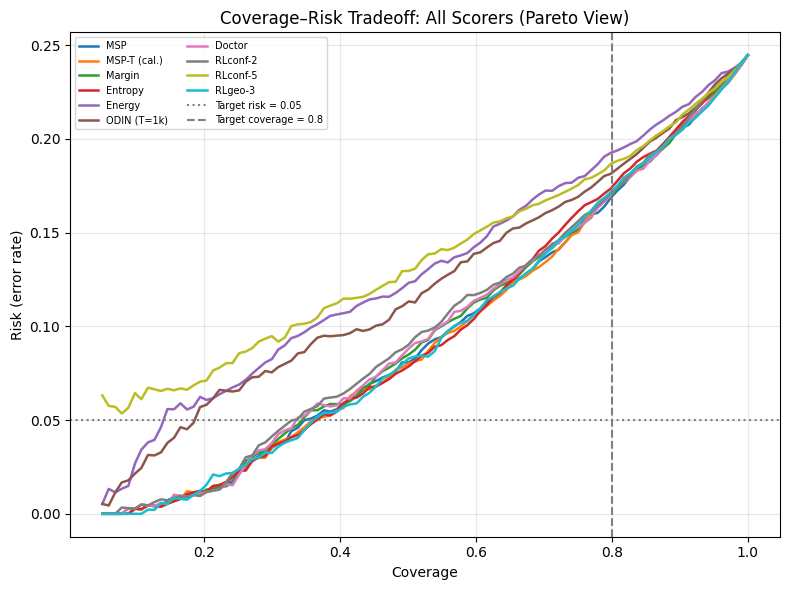

In [ ]:
# Pareto frontier plot: each point is (coverage, risk) at a specific threshold
# The ideal is bottom-right (high coverage, low risk)

fig, ax = plt.subplots(figsize=(8, 6))
cmap_p = plt.cm.get_cmap("tab10", len(advanced_scorers))

for i, (name, scores) in enumerate(advanced_scorers.items()):
    m = selective_metrics(preds, labels, scores, coverages=np.linspace(0.05, 1.0, 100))
    ax.plot(m["coverage"], m["risk"], color=cmap_p(i), lw=1.8, label=name)

ax.axhline(target_risk, color="gray", linestyle=":", label=f"Target risk = {target_risk}")
ax.axvline(target_coverage, color="gray", linestyle="--", label=f"Target coverage = {target_coverage}")
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk (error rate)")
ax.set_title("Coverage–Risk Tradeoff: All Scorers (Pareto View)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
p = os.path.join(config["results_dir"], "pareto_coverage_risk.png")
plt.savefig(p, dpi=150)
plt.show()